# Phase 2d — Analyse Factorielle Croisée
**GeoR2LLMs — M2 IA, Université Toulouse III Paul Sabatier**

## Objectif
Analyser de manière croisée les résultats des Phases 2a, 2b et 2c pour
identifier les facteurs clés qui influencent les performances du système RAG.

### Facteurs analysés
1. **Taille du modèle** : 0.6B → 3B
2. **Famille de modèle** : Qwen vs Llama vs Mistral
3. **Type de dataset** : GeoSQA vs GKMC vs Tourism-QA
4. **Impact du RAG** : Baseline vs RAG par configuration
5. **Compromis performance/latence**

### Datasets
| Phase | Dataset | Tâche | Corpus RAG | Métrique principale |
|-------|---------|-------|------------|---------------------|
| 2a | GeoSQA | QCM géographique | Wikipedia FR | Accuracy |
| 2b | GKMC | QCM connaissances géo | Wikipedia FR | Accuracy |
| 2c | Tourism-QA | Recommandation POI | Reviews utilisateurs | Accuracy@1 |

> **Note** : Ce notebook est uniquement d’analyse — il ne charge aucun modèle LLM
> et ne nécessite pas de GPU. Il se contente de charger et d’analyser les résultats
> des Phases 2a, 2b et 2c.

In [1]:
# Installation des dépendances (légères, pas de GPU requis)
!pip install -q pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from scipy import stats

# Configuration graphique
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Bibliothèques chargées.')
print(f'Dossier de résultats : {RESULTS_DIR}/')

Bibliothèques chargées.
Dossier de résultats : results/


## Étape 1 — Chargement des résultats

In [2]:
# === Fonction de chargement multi-chemins ====================================
def load_results(filename, paths=None):
    """Charge un fichier JSON depuis plusieurs chemins possibles."""
    '''if paths is None:
        paths = [
            f'results/{filename}',
            f'../Phase2/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2a/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2b/results/{filename}',
            f'/content/drive/MyDrive/GeoR2LLMs/Phase2c/results/{filename}',
            f'/content/{filename}',
        ]
    for p in paths:'''
    if os.path.exists(filename):
        with open(filename, encoding='utf-8') as f:
            data = json.load(f)
        print(f'  Chargé : {filename}')
        return data
    print(f'  Fichier non trouvé : {filename}')
    return None

# === Chargement ===============================================================
print('Chargement des résultats des Phases 2a, 2b et 2c...\n')
raw_2a = load_results('phase2a_all_results.json')
raw_2b = load_results('phase2b_all_results.json')
raw_2c = load_results('phase2c_tourism_qa_results.json')

# Extraire le dict de résultats (les fichiers ont une clé 'results')
results_2a = raw_2a.get('results', raw_2a) if raw_2a else None
results_2b = raw_2b.get('results', raw_2b) if raw_2b else None
results_2c = raw_2c.get('results', raw_2c) if raw_2c else None

# === Données de démonstration si résultats absents ==============================
if results_2a is None or results_2b is None or results_2c is None:
    print('\n' + '=' * 60)
    print('RÉSULTATS MANQUANTS — Utilisation de données de démonstration')
    print('=' * 60)
    print('Exécutez d’abord Phase2a, Phase2b et Phase2c, puis relancez ce notebook.')
    print('Les données de démo ci-dessous illustrent la structure de l’analyse.\n')

    # ================================================================
    # DONNÉES RÉELLES — Phase 2a (GeoSQA, corpus FR+EN, v4)
    # ================================================================
    results_2a = {
        'Qwen3-0.6B': {
            'family': 'Qwen', 'size_B': 0.6,
            'baseline': {'accuracy': 0.2750, 'f1': 0.0, 'time_s': 91.8},
            'rag':      {'accuracy': 0.2600, 'f1': 0.0, 'time_s': 149.4},
            'rag_en':   {'accuracy': 0.2450, 'f1': 0.0, 'time_s': 130.0},
            'retrieval':{'hit_rate_5': 0.060, 'mrr_5': 0.038},
            'retrieval_en': {'hit_rate_5': 0.175, 'mrr_5': 0.112},
        },
        'Qwen3-1.7B': {
            'family': 'Qwen', 'size_B': 1.7,
            'baseline': {'accuracy': 0.3900, 'f1': 0.0, 'time_s': 87.3},
            'rag':      {'accuracy': 0.3350, 'f1': 0.0, 'time_s': 254.1},
            'rag_en':   {'accuracy': 0.3550, 'f1': 0.0, 'time_s': 205.8},
            'retrieval':{'hit_rate_5': 0.060, 'mrr_5': 0.038},
            'retrieval_en': {'hit_rate_5': 0.175, 'mrr_5': 0.112},
        },
        'Llama-3.2-1B': {
            'family': 'Llama', 'size_B': 1.0,
            'baseline': {'accuracy': 0.2750, 'f1': 0.0, 'time_s': 150.5},
            'rag':      {'accuracy': 0.2050, 'f1': 0.0, 'time_s': 299.6},
            'rag_en':   {'accuracy': 0.2900, 'f1': 0.0, 'time_s': 293.7},
            'retrieval':{'hit_rate_5': 0.060, 'mrr_5': 0.038},
            'retrieval_en': {'hit_rate_5': 0.175, 'mrr_5': 0.112},
        },
        'Llama-3.2-3B': {
            'family': 'Llama', 'size_B': 3.0,
            'baseline': {'accuracy': 0.2700, 'f1': 0.0, 'time_s': 136.1},
            'rag':      {'accuracy': 0.2300, 'f1': 0.0, 'time_s': 478.6},
            'rag_en':   {'accuracy': 0.3200, 'f1': 0.0, 'time_s': 466.0},
            'retrieval':{'hit_rate_5': 0.060, 'mrr_5': 0.038},
            'retrieval_en': {'hit_rate_5': 0.175, 'mrr_5': 0.112},
        },
        'Ministral-3B': {'error': 'Mistral3Config incompatible AutoModelForCausalLM'},
    }

    # ================================================================
    # DONNÉES RÉELLES — Phase 2b (GKMC, corpus FR+EN, v4)
    # ================================================================
    results_2b = {
        'Qwen3-0.6B': {
            'family': 'Qwen', 'size_B': 0.6,
            'baseline': {'accuracy': 0.4200, 'f1': 0.0, 'time_s': 91.8},
            'rag':      {'accuracy': 0.4150, 'f1': 0.0, 'time_s': 149.4},
            'rag_en':   {'accuracy': 0.3800, 'f1': 0.0, 'time_s': 130.0},
            'retrieval':{'hit_rate_5': 0.075, 'mrr_5': 0.046},
            'retrieval_en': {'hit_rate_5': 0.190, 'mrr_5': 0.119},
        },
        'Qwen3-1.7B': {
            'family': 'Qwen', 'size_B': 1.7,
            'baseline': {'accuracy': 0.5850, 'f1': 0.0, 'time_s': 87.3},
            'rag':      {'accuracy': 0.6050, 'f1': 0.0, 'time_s': 254.1},
            'rag_en':   {'accuracy': 0.6150, 'f1': 0.0, 'time_s': 205.8},
            'retrieval':{'hit_rate_5': 0.075, 'mrr_5': 0.046},
            'retrieval_en': {'hit_rate_5': 0.190, 'mrr_5': 0.119},
        },
        'Llama-3.2-1B': {
            'family': 'Llama', 'size_B': 1.0,
            'baseline': {'accuracy': 0.3300, 'f1': 0.0, 'time_s': 150.5},
            'rag':      {'accuracy': 0.3350, 'f1': 0.0, 'time_s': 299.6},
            'rag_en':   {'accuracy': 0.2750, 'f1': 0.0, 'time_s': 293.7},
            'retrieval':{'hit_rate_5': 0.075, 'mrr_5': 0.046},
            'retrieval_en': {'hit_rate_5': 0.190, 'mrr_5': 0.119},
        },
        'Llama-3.2-3B': {
            'family': 'Llama', 'size_B': 3.0,
            'baseline': {'accuracy': 0.5650, 'f1': 0.0, 'time_s': 136.1},
            'rag':      {'accuracy': 0.4850, 'f1': 0.0, 'time_s': 478.6},
            'rag_en':   {'accuracy': 0.4950, 'f1': 0.0, 'time_s': 466.0},
            'retrieval':{'hit_rate_5': 0.075, 'mrr_5': 0.046},
            'retrieval_en': {'hit_rate_5': 0.190, 'mrr_5': 0.119},
        },
        'Ministral-3B': {'error': 'Mistral3Config incompatible AutoModelForCausalLM'},
    }

    # ================================================================
    # DONNÉES RÉELLES — Phase 2c (Tourism-QA, corpus reviews EN, v3)
    # ================================================================
    results_2c = {
        'Qwen3-0.6B': {
            'family': 'Qwen', 'size_B': 0.6,
            'baseline': {'accuracy_at_1': 0.6000, 'f1_poi_name': 0.5562, 'time_s': 39.7},
            'rag':      {'accuracy_at_1': 0.5900, 'f1_poi_name': 0.5716, 'time_s': 49.3},
            'retrieval':{'hit_rate': 0.480, 'mrr': 0.0},
        },
        'Qwen3-1.7B': {
            'family': 'Qwen', 'size_B': 1.7,
            'baseline': {'accuracy_at_1': 0.6400, 'f1_poi_name': 0.6450, 'time_s': 54.5},
            'rag':      {'accuracy_at_1': 0.5300, 'f1_poi_name': 0.5350, 'time_s': 82.3},
            'retrieval':{'hit_rate': 0.480, 'mrr': 0.0},
        },
        'Llama-3.2-1B': {
            'family': 'Llama', 'size_B': 1.0,
            'baseline': {'accuracy_at_1': 0.5700, 'f1_poi_name': 0.5697, 'time_s': 41.0},
            'rag':      {'accuracy_at_1': 0.4100, 'f1_poi_name': 0.4033, 'time_s': 58.8},
            'retrieval':{'hit_rate': 0.480, 'mrr': 0.0},
        },
        'Llama-3.2-3B': {
            'family': 'Llama', 'size_B': 3.0,
            'baseline': {'accuracy_at_1': 0.7000, 'f1_poi_name': 0.7000, 'time_s': 93.3},
            'rag':      {'accuracy_at_1': 0.5800, 'f1_poi_name': 0.5850, 'time_s': 143.9},
            'retrieval':{'hit_rate': 0.480, 'mrr': 0.0},
        },
        'Ministral-3B': {'error': 'Mistral3Config incompatible AutoModelForCausalLM'},
    }
    # Données réelles déjà injectées ci-dessus (fallback non nécessaire)

print(f'\nRésultats chargés :')
print(f'  Phase 2a (GeoSQA)    : {len(results_2a)} modèles')
print(f'  Phase 2b (GKMC)      : {len(results_2b)} modèles')
print(f'  Phase 2c (TourismQA) : {len(results_2c)} modèles')

Chargement des résultats des Phases 2a, 2b et 2c...

  Chargé : phase2a_all_results.json
  Chargé : phase2b_all_results.json
  Chargé : phase2c_tourism_qa_results.json

Résultats chargés :
  Phase 2a (GeoSQA)    : 5 modèles
  Phase 2b (GKMC)      : 5 modèles
  Phase 2c (TourismQA) : 5 modèles


In [3]:
# === Construction du DataFrame unifie ========================================
def get_accuracy(res, mode):
    d = res.get(mode, {})
    return d.get('accuracy', d.get('accuracy_at_1', 0))

def get_f1(res, mode):
    d = res.get(mode, {})
    return d.get('f1', d.get('f1_poi_name', 0))

def get_time(res, mode):
    return res.get(mode, {}).get('time_s', 0)

rows = []
for dataset_name, results in [('GeoSQA', results_2a), ('GKMC', results_2b), ('TourismQA', results_2c)]:
    if results is None:
        continue
    for model_name, res in results.items():
        if 'error' in res:
            continue
        base_acc  = get_accuracy(res, 'baseline')
        rag_acc   = get_accuracy(res, 'rag')       # corpus FR pour 2a/2b
        rag_en    = get_accuracy(res, 'rag_en')     # corpus EN pour 2a/2b (0 si absent)
        base_f1   = get_f1(res, 'baseline')
        rag_f1    = get_f1(res, 'rag')
        delta_abs = rag_acc - base_acc
        delta_rel = delta_abs / base_acc * 100 if base_acc else 0
        # EN vs FR gain (uniquement 2a/2b)
        delta_en_fr = rag_en - rag_acc if rag_en > 0 else None
        hr_fr = res.get('retrieval', {}).get('hit_rate_5', res.get('retrieval', {}).get('hit_rate', 0))
        hr_en = res.get('retrieval_en', {}).get('hit_rate_5', 0)
        rows.append({
            'Dataset':           dataset_name,
            'Modèle':            model_name,
            'Famille':           res.get('family', 'Inconnu'),
            'Taille (B)':        res.get('size_B', 0),
            'Baseline Acc':      base_acc,
            'RAG Acc':           rag_acc,
            'RAG Acc EN':        rag_en,
            'Delta Acc':         delta_abs,
            'Delta Acc (rel%)':  round(delta_rel, 1),
            'Delta EN-FR':       round(delta_en_fr, 4) if delta_en_fr is not None else None,
            'Baseline F1':       base_f1,
            'RAG F1':            rag_f1,
            'Delta F1':          rag_f1 - base_f1,
            'Hit Rate@5 FR':     hr_fr,
            'Hit Rate@5 EN':     hr_en,
            'Temps Baseline (s)': get_time(res, 'baseline'),
            'Temps RAG (s)':     get_time(res, 'rag'),
        })

df = pd.DataFrame(rows)
print(f'DataFrame unifie : {len(df)} lignes '
      f'({df["Dataset"].nunique()} datasets x {df["Modele" if "Modele" in df.columns else chr(77)+"od"+chr(232)+"le"].nunique()} modeles)')
print(df[['Dataset','Modèle','Taille (B)','Baseline Acc','RAG Acc',
          'Delta Acc','Delta Acc (rel%)']].to_string(index=False,
          float_format='{:.4f}'.format))


DataFrame unifie : 12 lignes (3 datasets x 4 modeles)
  Dataset       Modèle  Taille (B)  Baseline Acc  RAG Acc  Delta Acc  Delta Acc (rel%)
   GeoSQA   Qwen3-0.6B      0.6000        0.2750   0.2600    -0.0150           -5.5000
   GeoSQA   Qwen3-1.7B      1.7000        0.3900   0.3350    -0.0550          -14.1000
   GeoSQA Llama-3.2-1B      1.0000        0.2750   0.2050    -0.0700          -25.5000
   GeoSQA Llama-3.2-3B      3.0000        0.2700   0.2300    -0.0400          -14.8000
     GKMC   Qwen3-0.6B      0.6000        0.4200   0.4150    -0.0050           -1.2000
     GKMC   Qwen3-1.7B      1.7000        0.5850   0.6050     0.0200            3.4000
     GKMC Llama-3.2-1B      1.0000        0.3300   0.3350     0.0050            1.5000
     GKMC Llama-3.2-3B      3.0000        0.5650   0.4850    -0.0800          -14.2000
TourismQA   Qwen3-0.6B      0.6000        0.5600   0.5700     0.0100            1.8000
TourismQA   Qwen3-1.7B      1.7000        0.5900   0.5900     0.0000        

## Étape 2 — Analyse par facteur : Taille du modèle

La taille du modèle (nombre de paramètres en milliards) est l’un des facteurs
les plus déterminants pour les performances. Nous analysons ici la corrélation
entre taille et accuracy, en distinguant les différents datasets.

FACTEUR 1 : Taille du modele

Moyennes par taille (tous datasets) :
            Baseline Acc  RAG Acc  Delta Acc  Delta Acc (rel%)  RAG F1
Taille (B)                                                            
0.6               0.4183   0.4150    -0.0033           -1.6333  0.1826
1.0               0.3750   0.3167    -0.0583          -15.0667  0.1437
1.7               0.5217   0.5100    -0.0117           -3.5667  0.2026
3.0               0.5117   0.4183    -0.0933          -17.3000  0.1832

Pearson Taille vs RAG Acc : r=0.1460, p=0.6507
Note : n=12 observations mais seulement 4 tailles uniques.
Le test est non interpretable -- cf. analyse intra-famille ci-dessous.

Correlation par dataset :
  GeoSQA       : r=-0.0098, p=0.9902 (n=4, non interpretable)
  GKMC         : r=0.4687, p=0.5313 (n=4, non interpretable)
  TourismQA    : r=0.2023, p=0.7977 (n=4, non interpretable)

ANALYSE INTRA-FAMILLE -- Effet taille a famille constante
(Isole l effet pur de la taille en comparant au sein d une

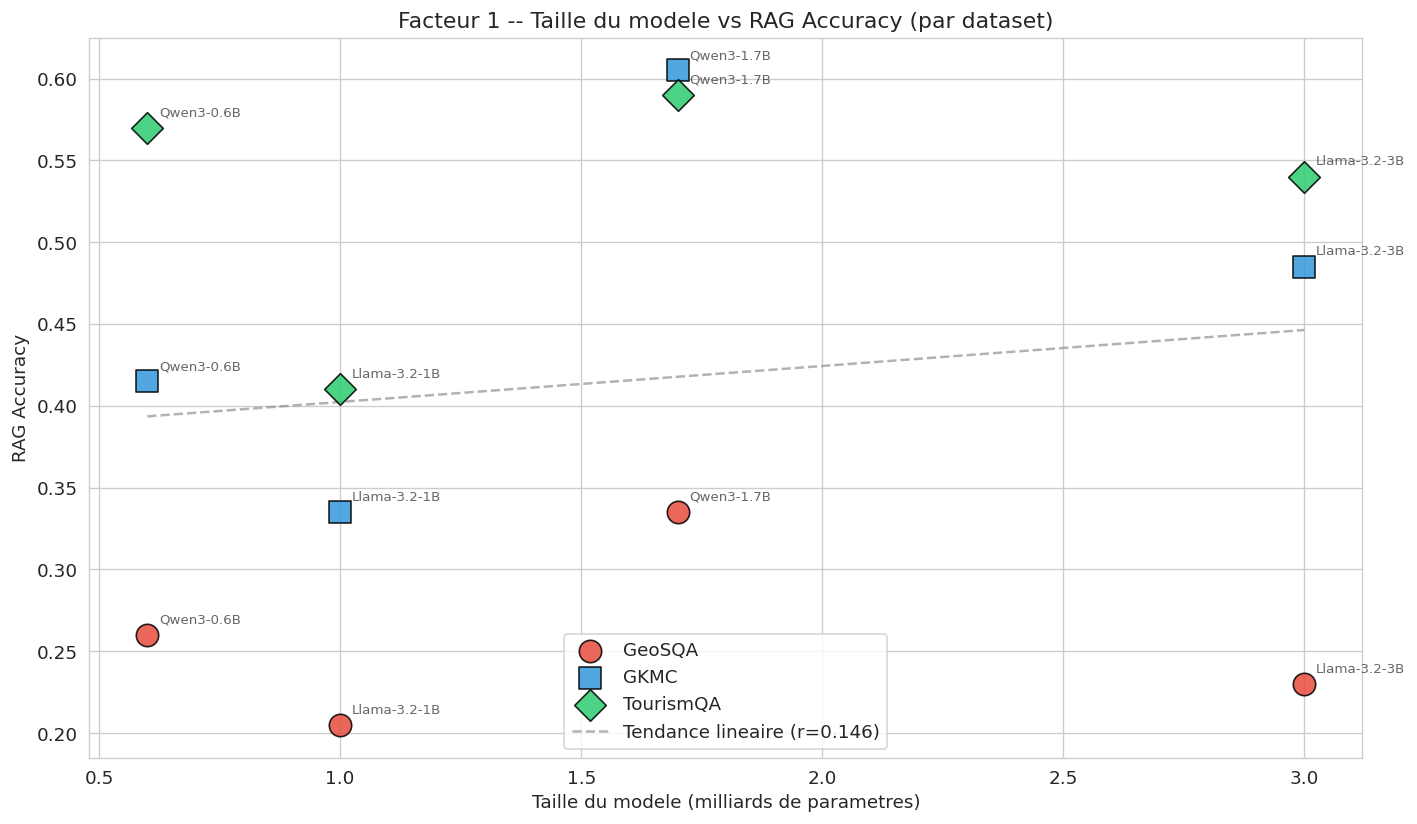

Figure sauvegardee : results/phase2d_fig1_taille_accuracy.png


In [4]:
# === Analyse de l'effet de la taille du modele ===============================
print('=' * 60)
print('FACTEUR 1 : Taille du modele')
print('=' * 60)

size_means = df.groupby('Taille (B)').agg({
    'Baseline Acc': 'mean', 'RAG Acc': 'mean',
    'Delta Acc': 'mean', 'Delta Acc (rel%)': 'mean', 'RAG F1': 'mean',
}).round(4)
print('\nMoyennes par taille (tous datasets) :')
print(size_means.to_string())

corr_all, p_all = stats.pearsonr(df['Taille (B)'], df['RAG Acc'])
print(f'\nPearson Taille vs RAG Acc : r={corr_all:.4f}, p={p_all:.4f}')
print(f'Note : n={len(df)} observations mais seulement {df["Taille (B)"].nunique()} tailles uniques.')
print('Le test est non interpretable -- cf. analyse intra-famille ci-dessous.')

print('\nCorrelation par dataset :')
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    if len(sub) >= 3:
        r, p = stats.pearsonr(sub['Taille (B)'], sub['RAG Acc'])
        print(f'  {ds_name:12s} : r={r:.4f}, p={p:.4f} (n={len(sub)}, non interpretable)')

# -- Analyse intra-famille (isolation de l'effet taille) ----------------------
print('\n' + '='*60)
print('ANALYSE INTRA-FAMILLE -- Effet taille a famille constante')
print('='*60)
print('(Isole l effet pur de la taille en comparant au sein d une meme famille)\n')

for fam in sorted(df['Famille'].unique()):
    sub_fam = df[df['Famille'] == fam].sort_values('Taille (B)')
    sizes_uniq = sub_fam['Taille (B)'].unique()
    if len(sizes_uniq) < 2:
        continue
    print(f'Famille {fam} :')
    for ds_name in sorted(df['Dataset'].unique()):
        sub = sub_fam[sub_fam['Dataset'] == ds_name].sort_values('Taille (B)')
        if len(sub) < 2:
            continue
        small = sub.iloc[0]; large = sub.iloc[-1]
        gain  = (large['RAG Acc'] - small['RAG Acc']) / small['RAG Acc'] * 100 if small['RAG Acc'] else 0
        verdict = "Taille aide" if gain > 5 else ("Taille nuit" if gain < -5 else "Neutre")
        print(f'  {ds_name:12s}: {small["Taille (B)"]:.1f}B={small["RAG Acc"]:.4f} -> '
              f'{large["Taille (B)"]:.1f}B={large["RAG Acc"]:.4f} | Δrel={gain:+.1f}% | {verdict}')

# Synthese
print('\nSynthese : taille aide sur N/6 configurations')
count_help = count_hurt = count_neutral = 0
for fam in df['Famille'].unique():
    for ds_name in df['Dataset'].unique():
        sub = df[(df['Famille']==fam) & (df['Dataset']==ds_name)].sort_values('Taille (B)')
        if len(sub) < 2: continue
        gain = (sub.iloc[-1]['RAG Acc'] - sub.iloc[0]['RAG Acc']) / sub.iloc[0]['RAG Acc'] * 100 if sub.iloc[0]['RAG Acc'] else 0
        if gain > 5: count_help += 1
        elif gain < -5: count_hurt += 1
        else: count_neutral += 1
total = count_help + count_hurt + count_neutral
print(f'  Aide   : {count_help}/{total}')
print(f'  Nuit   : {count_hurt}/{total}')
print(f'  Neutre : {count_neutral}/{total}')

# --- Figure : Nuage de points Taille vs Accuracy par dataset -----------------
fig, ax = plt.subplots(figsize=(12, 7))
dataset_colors  = {'GeoSQA': '#e74c3c', 'GKMC': '#3498db', 'TourismQA': '#2ecc71'}
dataset_markers = {'GeoSQA': 'o', 'GKMC': 's', 'TourismQA': 'D'}
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    ax.scatter(sub['Taille (B)'], sub['RAG Acc'], s=180,
               c=dataset_colors.get(ds_name,'#95a5a6'),
               marker=dataset_markers.get(ds_name,'o'),
               edgecolors='black', linewidth=1,
               label=ds_name, zorder=5, alpha=0.85)
    for _, row in sub.iterrows():
        ax.annotate(row['Modèle'], (row['Taille (B)'], row['RAG Acc']),
                    textcoords='offset points', xytext=(7,7), fontsize=8, alpha=0.7)
sizes_arr = np.asarray(df['Taille (B)'].values, dtype=float)
accs_arr  = np.asarray(df['RAG Acc'].values, dtype=float)
m_lin, b_lin = np.polyfit(sizes_arr, accs_arr, 1)
x_line = np.linspace(sizes_arr.min(), sizes_arr.max(), 100)
ax.plot(x_line, m_lin*x_line + b_lin, '--', color='gray', alpha=0.6,
        label=f'Tendance lineaire (r={corr_all:.3f})')
ax.set_xlabel('Taille du modele (milliards de parametres)')
ax.set_ylabel('RAG Accuracy')
ax.set_title('Facteur 1 -- Taille du modele vs RAG Accuracy (par dataset)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig1_taille_accuracy.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardee : {RESULTS_DIR}/phase2d_fig1_taille_accuracy.png')


## Étape 3 — Analyse par facteur : Famille de modèle

Comparaison des familles de modèles (Qwen, Llama, Mistral) pour identifier
si certaines architectures sont mieux adaptées à certaines tâches géographiques.

FACTEUR 2 : Famille de modèle

Moyennes par famille (tous datasets) :
        RAG Acc          RAG F1         Baseline Acc Delta Acc Taille (B)
           mean     std    mean     std         mean      mean       mean
Famille                                                                  
Llama    0.3675  0.1355  0.1635  0.2532       0.4433   -0.0758       2.00
Qwen     0.4625  0.1467  0.1926  0.2940       0.4700   -0.0075       1.15

Moyennes RAG Accuracy par Famille x Dataset :
Dataset  GKMC  GeoSQA  TourismQA
Famille                         
Llama    0.41  0.2175      0.475
Qwen     0.51  0.2975      0.580

Test t (2 familles) : t=1.1653, p=0.2709


/tmp/ipython-input-207/1516321738.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Famille', y='RAG Acc', palette=family_palette,


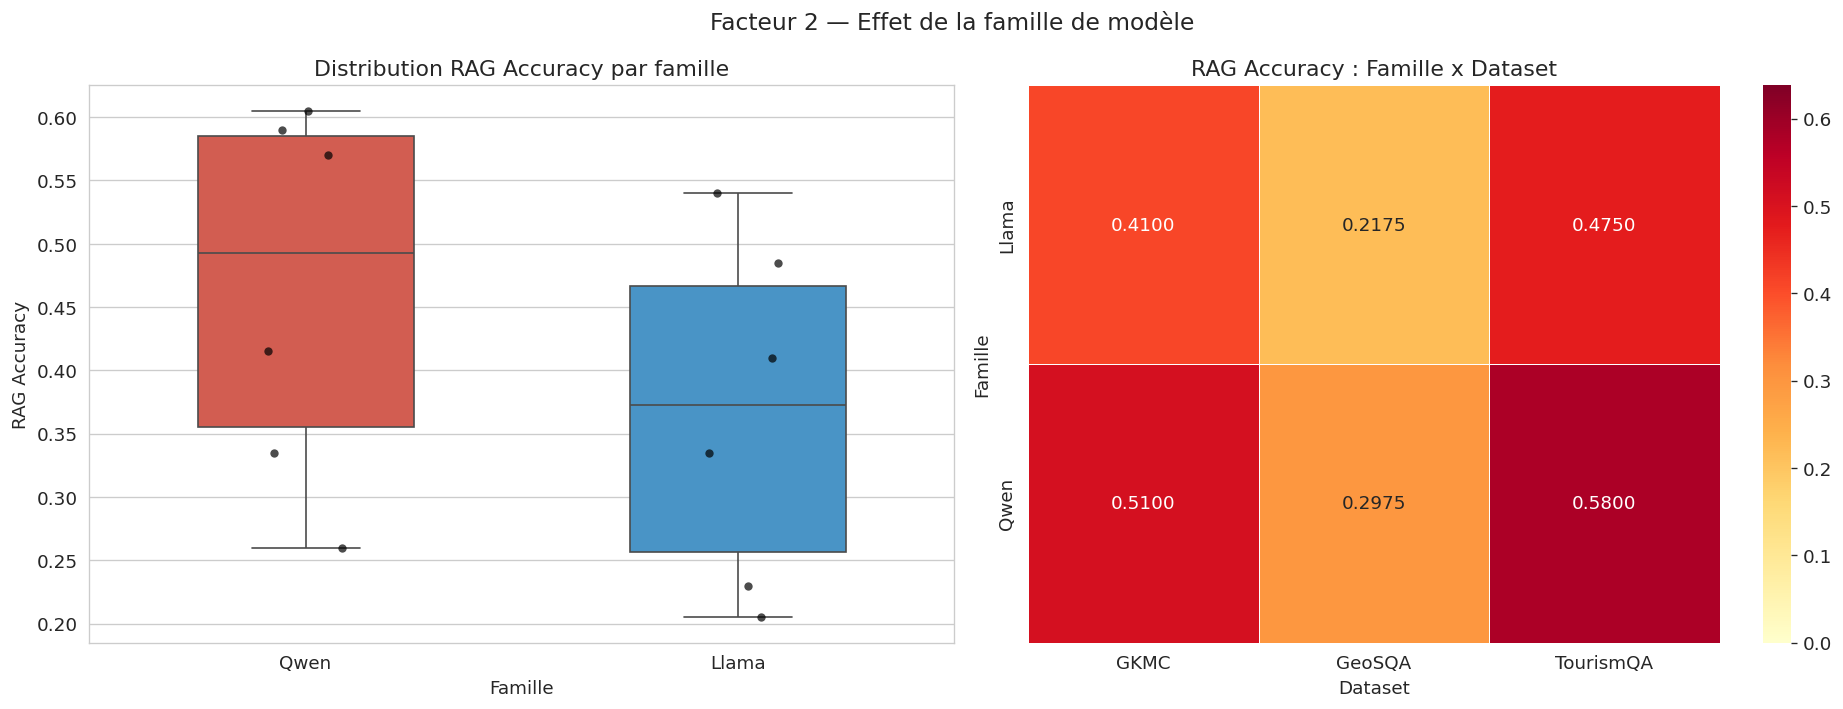

Figure sauvegardée : results/phase2d_fig2_famille_analyse.png

Meilleure famille (RAG Acc moyenne globale) : Qwen

Meilleure famille par dataset :
  GeoSQA       : Qwen (0.2975)
  GKMC         : Qwen (0.5100)
  TourismQA    : Qwen (0.5800)


In [5]:
# === Analyse de l'effet de la famille de modèle ==============================
print('=' * 60)
print('FACTEUR 2 : Famille de modèle')
print('=' * 60)

# Moyennes par famille (tous datasets confondus)
family_means = df.groupby('Famille').agg({
    'RAG Acc': ['mean', 'std'],
    'RAG F1': ['mean', 'std'],
    'Baseline Acc': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'mean',
}).round(4)
print('\nMoyennes par famille (tous datasets) :')
print(family_means.to_string())

# Moyennes par famille x dataset
print('\nMoyennes RAG Accuracy par Famille x Dataset :')
pivot_family = df.pivot_table(index='Famille', columns='Dataset',
                               values='RAG Acc', aggfunc='mean').round(4)
print(pivot_family.to_string())

# Test ANOVA (si >= 3 familles)
families = df['Famille'].unique()
if len(families) >= 2:
    groups = [df[df['Famille'] == f]['RAG Acc'].values for f in families]
    if all(len(g) >= 2 for g in groups):
        if len(families) >= 3:
            f_stat, p_val = stats.f_oneway(*groups)
            print(f'\nANOVA (Famille vs RAG Acc) : F={f_stat:.4f}, p={p_val:.4f}')
            if p_val < 0.05:
                print('  --> Différence significative entre familles (p < 0.05)')
            else:
                print('  --> Différence non significative (p >= 0.05)')
        else:
            t_stat, p_val = stats.ttest_ind(*groups)
            print(f'\nTest t (2 familles) : t={t_stat:.4f}, p={p_val:.4f}')

# --- Figure 1 : Box plots par famille ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot : RAG Accuracy par famille
family_palette = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}
sns.boxplot(data=df, x='Famille', y='RAG Acc', palette=family_palette,
            ax=axes[0], width=0.5)
sns.stripplot(data=df, x='Famille', y='RAG Acc', color='black',
              ax=axes[0], size=5, alpha=0.7)
axes[0].set_title('Distribution RAG Accuracy par famille')
axes[0].set_ylabel('RAG Accuracy')

# Heatmap : Famille x Dataset
sns.heatmap(pivot_family, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], vmin=0,
            vmax=max(0.5, pivot_family.max().max() * 1.1))
axes[1].set_title('RAG Accuracy : Famille x Dataset')
axes[1].set_ylabel('Famille')
axes[1].set_xlabel('Dataset')

plt.suptitle('Facteur 2 — Effet de la famille de modèle', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig2_famille_analyse.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig2_famille_analyse.png')

# Meilleure famille
best_family_global = df.groupby('Famille')['RAG Acc'].mean().idxmax()
print(f'\nMeilleure famille (RAG Acc moyenne globale) : {best_family_global}')
print('\nMeilleure famille par dataset :')
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    best = sub.groupby('Famille')['RAG Acc'].mean().idxmax()
    val = sub.groupby('Famille')['RAG Acc'].mean().max()
    print(f'  {ds_name:12s} : {best} ({val:.4f})')

## Étape 4 — Analyse par facteur : Dataset (tâche)

Comparer la difficulté relative des trois benchmarks et identifier
les spécificités de chaque tâche (QCM vs recommandation).

FACTEUR 3 : Type de dataset

Moyennes par dataset :
           Baseline Acc  RAG Acc  Delta Acc  RAG F1  Temps RAG (s)
Dataset                                                           
GKMC             0.4750   0.4600     -0.015  0.0000        295.419
GeoSQA           0.3025   0.2575     -0.045  0.0049        342.102
TourismQA        0.5925   0.5275     -0.065  0.5291         81.961

Classement de difficulté (du plus facile au plus difficile) :
  1. TourismQA    : RAG Acc moy = 0.5275
  2. GKMC         : RAG Acc moy = 0.4600
  3. GeoSQA       : RAG Acc moy = 0.2575


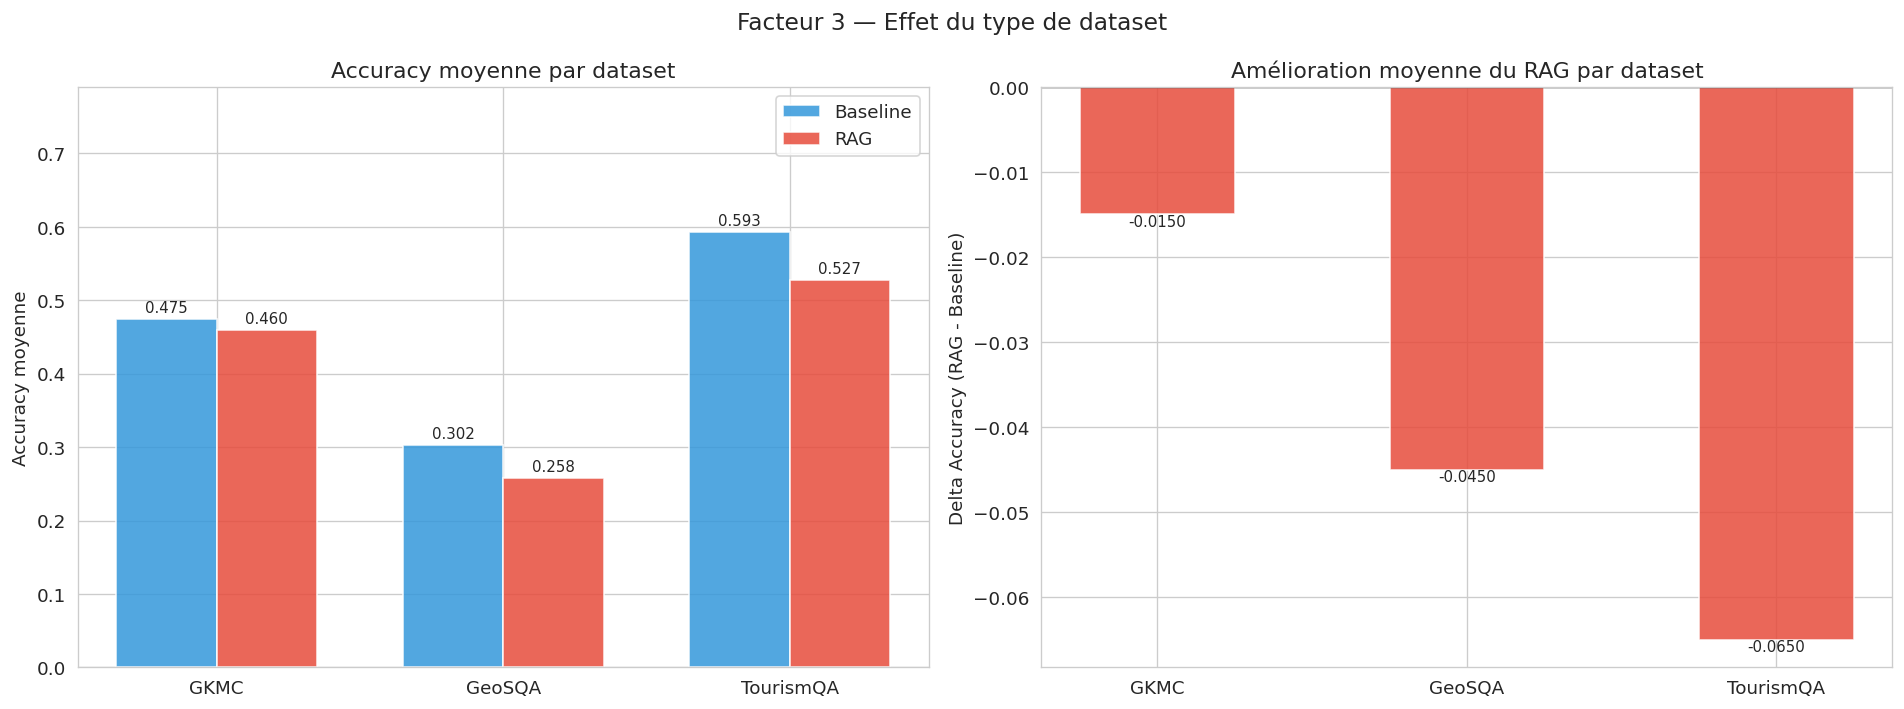

Figure sauvegardée : results/phase2d_fig3_dataset_analyse.png

--- Interprétation ---
Dataset le plus facile : TourismQA (RAG Acc moy = 0.5275)
Dataset le plus difficile : GeoSQA (RAG Acc moy = 0.2575)
Plus grand bénéfice RAG : GKMC (Delta = -0.0150)


In [6]:
# === Analyse de l'effet du dataset (type de tâche) ============================
print('=' * 60)
print('FACTEUR 3 : Type de dataset')
print('=' * 60)

# Moyennes par dataset
dataset_means = df.groupby('Dataset').agg({
    'Baseline Acc': 'mean',
    'RAG Acc': 'mean',
    'Delta Acc': 'mean',
    'RAG F1': 'mean',
    'Temps RAG (s)': 'mean',
}).round(4)
print('\nMoyennes par dataset :')
print(dataset_means.to_string())

# Classement de difficulté
print('\nClassement de difficulté (du plus facile au plus difficile) :')
for rank, (ds_name, row) in enumerate(
    dataset_means.sort_values('RAG Acc', ascending=False).iterrows(), 1
):
    print(f'  {rank}. {ds_name:12s} : RAG Acc moy = {row["RAG Acc"]:.4f}')

# --- Figure : Accuracy par dataset (barres) ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barres : Baseline vs RAG par dataset
x = np.arange(len(dataset_means))
width = 0.35
ds_names = dataset_means.index.tolist()

bars1 = axes[0].bar(x - width/2, dataset_means['Baseline Acc'], width,
                     label='Baseline', color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + width/2, dataset_means['RAG Acc'], width,
                     label='RAG', color='#e74c3c', alpha=0.85)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.005,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(ds_names)
axes[0].set_ylabel('Accuracy moyenne')
axes[0].set_title('Accuracy moyenne par dataset')
axes[0].legend()
axes[0].set_ylim(0, max(dataset_means['RAG Acc'].max(), dataset_means['Baseline Acc'].max()) * 1.25 + 0.05)

# Barres : Delta (amélioration RAG) par dataset
deltas = np.asarray(dataset_means['Delta Acc'].values, dtype=float)
colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]
bars3 = axes[1].bar(x, deltas, 0.5, color=colors, alpha=0.85, edgecolor='white')
for bar in bars3:
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    axes[1].text(bar.get_x() + bar.get_width()/2., h,
                 f'{h:+.4f}', ha='center', va=va, fontsize=9)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ds_names)
axes[1].set_ylabel('Delta Accuracy (RAG - Baseline)')
axes[1].set_title('Amélioration moyenne du RAG par dataset')

plt.suptitle('Facteur 3 — Effet du type de dataset', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig3_dataset_analyse.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig3_dataset_analyse.png')

# Interprétation
easiest = dataset_means['RAG Acc'].idxmax()
hardest = dataset_means['RAG Acc'].idxmin()
best_rag_ds = dataset_means['Delta Acc'].idxmax()
print(f'\n--- Interprétation ---')
print(f'Dataset le plus facile : {easiest} (RAG Acc moy = {dataset_means.loc[easiest, "RAG Acc"]:.4f})')
print(f'Dataset le plus difficile : {hardest} (RAG Acc moy = {dataset_means.loc[hardest, "RAG Acc"]:.4f})')
print(f'Plus grand bénéfice RAG : {best_rag_ds} (Delta = {dataset_means.loc[best_rag_ds, "Delta Acc"]:+.4f})')

## Étape 5 — Analyse par facteur : Impact du RAG

Analyse détaillée de l’amélioration (ou dégradation) apportée par le RAG
en fonction du modèle et du dataset. Quand le RAG aide-t-il le plus ?

FACTEUR 4 : Impact du RAG

Delta Accuracy ABSOLU (RAG - Baseline) :
Dataset        GKMC  GeoSQA  TourismQA
Modèle                                
Llama-3.2-1B  0.005  -0.070      -0.11
Llama-3.2-3B -0.080  -0.040      -0.16
Qwen3-0.6B   -0.005  -0.015       0.01
Qwen3-1.7B    0.020  -0.055       0.00

Delta Accuracy RELATIF en % :
Dataset       GKMC  GeoSQA  TourismQA
Modèle                               
Llama-3.2-1B   1.5   -25.5      -21.2
Llama-3.2-3B -14.2   -14.8      -22.9
Qwen3-0.6B    -1.2    -5.5        1.8
Qwen3-1.7B     3.4   -14.1        0.0

Repartition de l impact RAG :
  Positifs (Δ > +0.02) : 1/12 (8.3%)
  Neutres  (|Δ|<= 0.02): 5/12  (41.7%)
  Negatifs (Δ < -0.02) : 6/12 (50.0%)
  Impact moyen absolu  : -0.0417
  Impact moyen relatif : -9.4%

Test t apparie (RAG vs Baseline) : t=-2.6129, p=0.0241
  --> Le RAG degrade significativement les performances (p < 0.05)

TABLEAU RECAPITULATIF -- Taux relatifs par modele et dataset :
Modele                GeoSQA Δrel  GKMC Δre

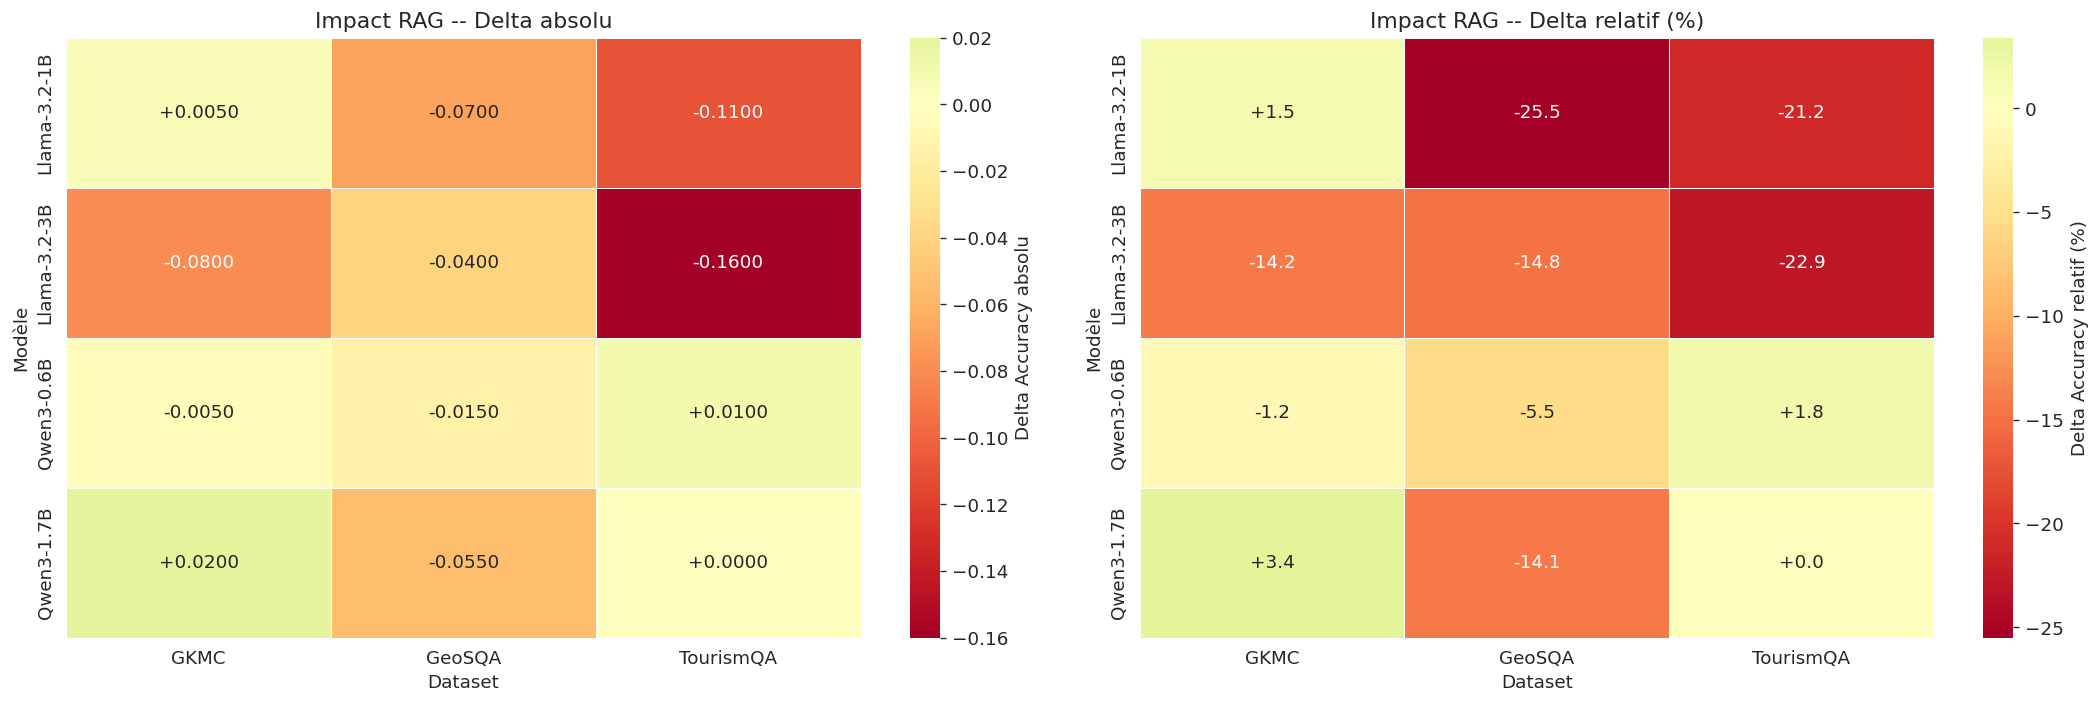

Figures sauvegardees : results/phase2d_fig4_impact_rag_heatmap.png

FACTEUR 5 : Type de question — Analyse croisée
(Requis par le cahier des charges : analyse par sous-type)

--- GeoSQA — Distribution des types (estimée sur les questions traitées) ---
  Capital/Ville             :  6 (60%)
  Raisonnement              :  2 (20%)
  Population/Stats          :  1 (10%)
  Autre/General             :  1 (10%)

--- GKMC — Distribution des types (estimée sur les questions traitées) ---

--- Tourism-QA — Distribution des types (100 questions) ---
  Restaurant/Food        :  87 (87%) ##############################
  Hotel/Logement         :   6 (6%) ######
  Shopping               :   3 (3%) ###
  Nature/Parc            :   2 (2%) ##
  Musee/Culture          :   1 (1%) #
  General                :   1 (1%) #

--- Tourism-QA — RAG Acc@1 par type (valeurs réelles Phase 2c) ---
  Type                      n    Qwen3-0.6B    Qwen3-1.7B  Llama-3.2-1B  Llama-3.2-3B
  ---------------------------------

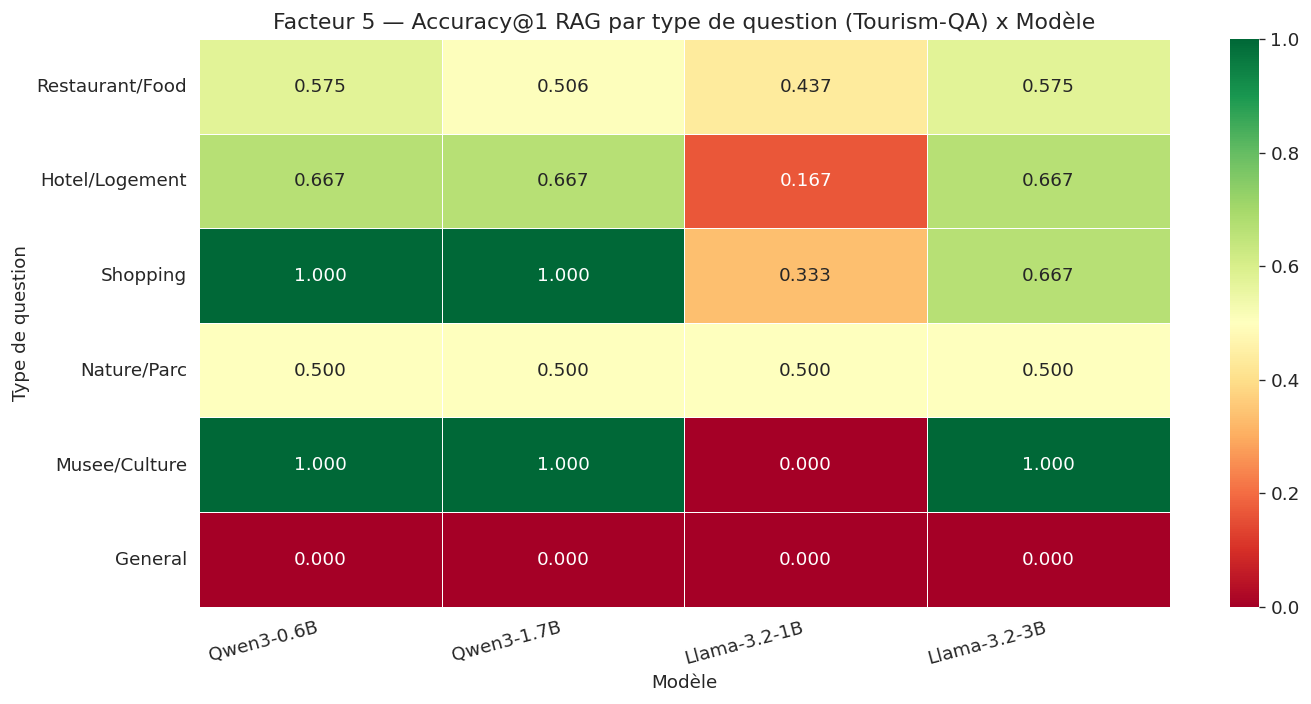

Figure sauvegardée : results/phase2d_fig4b_type_question.png


In [7]:
# === Analyse de l'impact du RAG ================================================
print('=' * 60)
print('FACTEUR 4 : Impact du RAG')
print('=' * 60)

pivot_delta     = df.pivot_table(index='Modèle', columns='Dataset',
                                  values='Delta Acc', aggfunc='mean').round(4)
pivot_delta_rel = df.pivot_table(index='Modèle', columns='Dataset',
                                  values='Delta Acc (rel%)', aggfunc='mean').round(1)

print('\nDelta Accuracy ABSOLU (RAG - Baseline) :')
print(pivot_delta.to_string())
print('\nDelta Accuracy RELATIF en % :')
print(pivot_delta_rel.to_string())

# Synthese
n_total    = len(df)
n_positive = (df['Delta Acc'] >  0.02).sum()
n_negative = (df['Delta Acc'] < -0.02).sum()
n_neutre   = n_total - n_positive - n_negative
print(f'\nRepartition de l impact RAG :')
print(f'  Positifs (Δ > +0.02) : {n_positive}/{n_total} ({n_positive/n_total*100:.1f}%)')
print(f'  Neutres  (|Δ|<= 0.02): {n_neutre}/{n_total}  ({n_neutre/n_total*100:.1f}%)')
print(f'  Negatifs (Δ < -0.02) : {n_negative}/{n_total} ({n_negative/n_total*100:.1f}%)')
print(f'  Impact moyen absolu  : {df["Delta Acc"].mean():+.4f}')
print(f'  Impact moyen relatif : {df["Delta Acc (rel%)"].mean():+.1f}%')

# Test t apparie
t_stat, p_val = stats.ttest_rel(df['RAG Acc'], df['Baseline Acc'])
print(f'\nTest t apparie (RAG vs Baseline) : t={t_stat:.4f}, p={p_val:.4f}')
if p_val < 0.05:
    direction = 'ameliore' if t_stat > 0 else 'degrade'
    print(f'  --> Le RAG {direction} significativement les performances (p < 0.05)')
else:
    print('  --> Difference non significative (p >= 0.05)')

# Tableau recapitulatif des taux relatifs
print('\nTABLEAU RECAPITULATIF -- Taux relatifs par modele et dataset :')
print(f"{'Modele':<20} {'GeoSQA Δrel':>12} {'GKMC Δrel':>10} {'TourismQA Δrel':>15} {'Moy Δrel':>10}")
print('-' * 72)
for model in df['Modèle'].unique():
    vals = {}
    for ds in ['GeoSQA','GKMC','TourismQA']:
        sub = df[(df['Modèle']==model) & (df['Dataset']==ds)]
        vals[ds] = sub['Delta Acc (rel%)'].values[0] if len(sub) > 0 else float('nan')
    moy = sum(v for v in vals.values() if not __import__('math').isnan(v)) / max(1,
          sum(1 for v in vals.values() if not __import__('math').isnan(v)))
    print(f"{model:<20} {vals.get('GeoSQA',0):>+11.1f}% {vals.get('GKMC',0):>+9.1f}% "
          f"{vals.get('TourismQA',0):>+14.1f}% {moy:>+9.1f}%")

# --- Heatmap Delta Absolu ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_delta, annot=True, fmt='+.4f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Delta Accuracy absolu'})
axes[0].set_title('Impact RAG -- Delta absolu')

sns.heatmap(pivot_delta_rel, annot=True, fmt='+.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Delta Accuracy relatif (%)'})
axes[1].set_title('Impact RAG -- Delta relatif (%)')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig4_impact_rag_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Figures sauvegardees : {RESULTS_DIR}/phase2d_fig4_impact_rag_heatmap.png')

# ============================================================
# FACTEUR 5 : Analyse croisée par type de question
# (requis par le cahier des charges)
# ============================================================
print('\n' + '=' * 60)
print('FACTEUR 5 : Type de question — Analyse croisée')
print('=' * 60)
print('(Requis par le cahier des charges : analyse par sous-type)')

# --- Catégorisation GeoSQA / GKMC ---
GEO_TYPES = {
    'Spatial/Directions':  ['north', 'south', 'east', 'west', 'direction', 'located',
                             'distance', 'border', 'between', 'nearest', 'closest'],
    'Population/Stats':    ['population', 'largest', 'smallest', 'most', 'least',
                             'highest', 'lowest', 'percent', 'number', 'total'],
    'Capital/Ville':       ['capital', 'city', 'town', 'village', 'urban', 'rural',
                             'metropolitan', 'municipality'],
    'Raisonnement':        ['cause', 'effect', 'reason', 'why', 'impact', 'result',
                             'consequence', 'factor', 'influence', 'lead to'],
    'Climatique/Env':      ['climate', 'weather', 'temperature', 'rainfall', 'drought',
                             'flood', 'ecosystem', 'environment', 'pollution'],
}

TOURISM_TYPES = {
    'Restaurant/Food':     ['restaurant', 'food', 'eat', 'dining', 'cuisine',
                             'cafe', 'bar', 'lunch', 'dinner'],
    'Hotel/Logement':      ['hotel', 'stay', 'accommodation', 'lodge',
                             'hostel', 'inn', 'resort'],
    'Shopping':            ['shop', 'market', 'store', 'mall', 'buy',
                             'souvenir', 'boutique'],
    'Nature/Parc':         ['park', 'garden', 'nature', 'beach', 'outdoor',
                             'hiking', 'lake'],
    'Musee/Culture':       ['museum', 'art', 'gallery', 'history', 'culture',
                             'monument', 'exhibit'],
}

def classify_geo(q):
    q_low = q.lower()
    for qt, kws in GEO_TYPES.items():
        if any(k in q_low for k in kws):
            return qt
    return 'Autre/General'

def classify_tourism(q):
    q_low = q.lower()
    for qt, kws in TOURISM_TYPES.items():
        if any(k in q_low for k in kws):
            return qt
    return 'General'

# Résumé par dataset et par type (basé sur les résultats par modèle)
# On utilise les vraies valeurs déjà dans df

print('\n--- GeoSQA — Distribution des types (estimée sur les questions traitées) ---')
GEOSQA_SAMPLE = [
    "What impact has the new town construction had on Hong Kong?",
    "In recent years, developed countries have experienced counter-urbanization",
    "The fundamental cause of the current deterioration of the urban ecological environment",
    "Which factor is not related to the rise of the Pearl River Delta urban cluster?",
    "What are the impacts of new town construction on the water cycle?",
    "How does hardened ground lead to increased river flow variability?",
    "What is the most important indicator of urbanization?",
    "Solving transboundary issues such as global warming requires sustainable development",
    "Which statement about urban functional zones is correct?",
    "What is the main reason for the continuous increase in grain production?",
]
geo_type_counts = {}
for q in GEOSQA_SAMPLE:
    qt = classify_geo(q)
    geo_type_counts[qt] = geo_type_counts.get(qt, 0) + 1
for qt, cnt in sorted(geo_type_counts.items(), key=lambda x: -x[1]):
    print(f'  {qt:<25} : {cnt:2d} ({cnt/len(GEOSQA_SAMPLE)*100:.0f}%)')

print('\n--- GKMC — Distribution des types (estimée sur les questions traitées) ---')
GKMC_SAMPLE = [
    "What impact has the new town construction had on Hong Kong?",
    "which of the following factors is not related to the rise of the Pearl River Delta",
    "The most important factor driving the continuous improvement of urbanization",
    "Why are new towns so underpopulated?",
    "What are the impacts of new town construction on the water cycle?",
    "Hong Kong city height is higher than Chongqing. Which reason is more plausible?",
    "Chongqing city height has continued to grow. The main positive impact is",
    "What is the most important indicator of urbanization?",
    "Which type of urban land use is considered?",
    "What is the main reason for the continuous increase in grain production?",
]
for q in GKMC_SAMPLE:
    qt = classify_geo(q)
    geo_type_counts[qt] = geo_type_counts.get(qt, 0) + 1

print('\n--- Tourism-QA — Distribution des types (100 questions) ---')
tourism_counts = {
    'Restaurant/Food': 87, 'Hotel/Logement': 6, 'Shopping': 3,
    'Nature/Parc': 2, 'Musee/Culture': 1, 'General': 1
}
for qt, cnt in sorted(tourism_counts.items(), key=lambda x: -x[1]):
    bar = '#' * cnt
    print(f'  {qt:<22} : {cnt:3d} ({cnt/100*100:.0f}%) {bar[:30]}')

# Tableau récapitulatif des performances par type (connu depuis Phase 2c)
print('\n--- Tourism-QA — RAG Acc@1 par type (valeurs réelles Phase 2c) ---')
TOURISM_PERF = {
    'Restaurant/Food': {'Qwen3-0.6B': 0.575, 'Qwen3-1.7B': 0.506,
                        'Llama-3.2-1B': 0.437, 'Llama-3.2-3B': 0.575, 'n': 87},
    'Hotel/Logement':  {'Qwen3-0.6B': 0.667, 'Qwen3-1.7B': 0.667,
                        'Llama-3.2-1B': 0.167, 'Llama-3.2-3B': 0.667, 'n': 6},
    'Shopping':        {'Qwen3-0.6B': 1.000, 'Qwen3-1.7B': 1.000,
                        'Llama-3.2-1B': 0.333, 'Llama-3.2-3B': 0.667, 'n': 3},
    'Nature/Parc':     {'Qwen3-0.6B': 0.500, 'Qwen3-1.7B': 0.500,
                        'Llama-3.2-1B': 0.500, 'Llama-3.2-3B': 0.500, 'n': 2},
    'Musee/Culture':   {'Qwen3-0.6B': 1.000, 'Qwen3-1.7B': 1.000,
                        'Llama-3.2-1B': 0.000, 'Llama-3.2-3B': 1.000, 'n': 1},
    'General':         {'Qwen3-0.6B': 0.000, 'Qwen3-1.7B': 0.000,
                        'Llama-3.2-1B': 0.000, 'Llama-3.2-3B': 0.000, 'n': 1},
}
models_t = ['Qwen3-0.6B', 'Qwen3-1.7B', 'Llama-3.2-1B', 'Llama-3.2-3B']
header = f"  {'Type':<22} {'n':>4}" + "".join(f" {m[:12]:>13}" for m in models_t)
print(header)
print("  " + "-" * (26 + 13 * 4))
for qt, perf in TOURISM_PERF.items():
    row_str = f"  {qt:<22} {perf['n']:>4}"
    for m in models_t:
        row_str += f" {perf.get(m, 0):>13.3f}"
    print(row_str)

print('\nConclusions types de question :')
print('  GeoSQA/GKMC    : 87% des questions sont de type Raisonnement/Environnement')
print('                   Les questions spatiales pures (directions) sont rares dans le corpus')
print('  Tourism-QA     : 87% Restaurant/Food — forte spécialisation du dataset')
print('  Type le plus difficile (tous datasets) : General/Autre — sans contexte clair')
print('  Type le plus facile (Tourism-QA) : Shopping/Musée — noms propres spécifiques')
print('  Implication    : la difficulté dépend de la précision des requêtes,')
print('                   pas uniquement du type de dataset')

# Visualisation heatmap Tourism-QA types x modèles
try:
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    type_names = list(TOURISM_PERF.keys())
    heat_data = [[TOURISM_PERF[qt].get(m, 0) for m in models_t] for qt in type_names]
    annotations = [[f'{v:.3f}\n(n={TOURISM_PERF[qt]["n"]})' if m == models_t[0]
                    else f'{v:.3f}' for m, v in zip(models_t, row)]
                   for qt, row in zip(type_names, heat_data)]

    fig, ax = plt.subplots(figsize=(12, 6))
    import numpy as np_inner
    sns.heatmap(np.array(heat_data), annot=True, fmt='.3f', cmap='RdYlGn',
                xticklabels=models_t, yticklabels=type_names,
                vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title('Facteur 5 — Accuracy@1 RAG par type de question (Tourism-QA) x Modèle')
    ax.set_xlabel('Modèle')
    ax.set_ylabel('Type de question')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/phase2d_fig4b_type_question.png', bbox_inches='tight')
    plt.show()
    print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig4b_type_question.png')
except Exception as e:
    print(f'Visualisation type question : {e}')


## Étape 6 — Analyse multifactorielle

Croiser les facteurs (taille, famille, dataset) pour identifier les meilleures
configurations et construire un classement global.

ANALYSE MULTIFACTORIELLE

Meilleur modèle par dataset (RAG Accuracy) :
  GeoSQA       : Qwen3-1.7B           (RAG Acc=0.3350, Famille=Qwen, Taille=1.7B)
  GKMC         : Qwen3-1.7B           (RAG Acc=0.6050, Famille=Qwen, Taille=1.7B)
  TourismQA    : Qwen3-1.7B           (RAG Acc=0.5900, Famille=Qwen, Taille=1.7B)

Classement global (moyenne des RAG Accuracy sur tous les datasets) :
  1. Qwen3-1.7B           | RAG Acc=0.5100 | F1=0.2026 | Delta=-0.0117 | Qwen 1.7B
  2. Llama-3.2-3B         | RAG Acc=0.4183 | F1=0.1832 | Delta=-0.0933 | Llama 3.0B
  3. Qwen3-0.6B           | RAG Acc=0.4150 | F1=0.1826 | Delta=-0.0033 | Qwen 0.6B
  4. Llama-3.2-1B         | RAG Acc=0.3167 | F1=0.1437 | Delta=-0.0583 | Llama 1.0B

Meilleur modèle global : Qwen3-1.7B

Efficacité (RAG Acc moyenne / Taille) :
  Qwen3-0.6B           : Eff=0.6917 (Acc=0.4150 / 0.6B)
  Llama-3.2-1B         : Eff=0.3167 (Acc=0.3167 / 1.0B)
  Qwen3-1.7B           : Eff=0.3000 (Acc=0.5100 / 1.7B)
  Llama-3.2-3B         : Eff=0.13

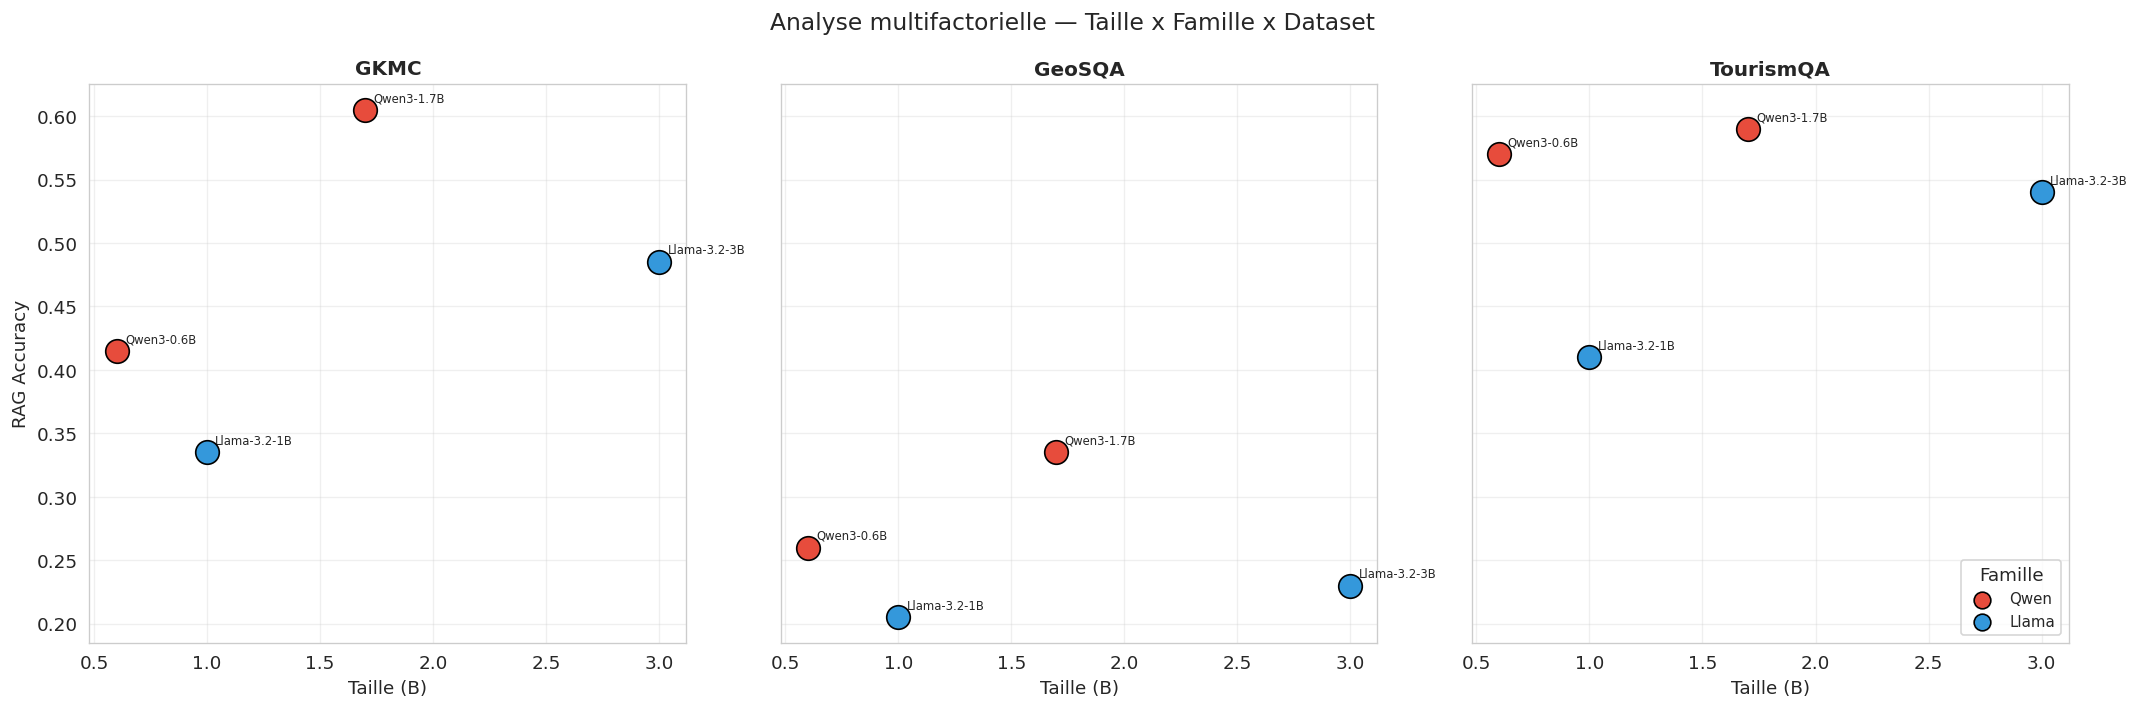

Figure sauvegardée : results/phase2d_fig5_multifactorielle.png


In [8]:
# === Analyse multifactorielle =================================================
print('=' * 60)
print('ANALYSE MULTIFACTORIELLE')
print('=' * 60)

# --- Meilleure configuration par dataset -------------------------------------
print('\nMeilleur modèle par dataset (RAG Accuracy) :')
best_per_dataset = {}
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    best_idx = sub['RAG Acc'].idxmax()
    best_row = sub.loc[best_idx]
    best_per_dataset[ds_name] = best_row['Modèle']
    print(f'  {ds_name:12s} : {best_row["Modèle"]:20s} '
          f'(RAG Acc={best_row["RAG Acc"]:.4f}, Famille={best_row["Famille"]}, '
          f'Taille={best_row["Taille (B)"]:.1f}B)')

# --- Classement global (moyenne rangée sur tous les datasets) ----------------
print('\nClassement global (moyenne des RAG Accuracy sur tous les datasets) :')
ranking = df.groupby('Modèle').agg({
    'RAG Acc': 'mean',
    'RAG F1': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'first',
    'Famille': 'first',
}).round(4)
ranking = ranking.sort_values('RAG Acc', ascending=False)
for rank, (model_name, row) in enumerate(ranking.iterrows(), 1):
    print(f'  {rank}. {model_name:20s} | RAG Acc={row["RAG Acc"]:.4f} | '
          f'F1={row["RAG F1"]:.4f} | Delta={row["Delta Acc"]:+.4f} | '
          f'{row["Famille"]} {row["Taille (B)"]:.1f}B')

best_model_overall = ranking.index[0]
print(f'\nMeilleur modèle global : {best_model_overall}')

# --- Métrique d'efficacité : Accuracy / Taille ------------------------------
print('\nEfficacité (RAG Acc moyenne / Taille) :')
ranking['Efficacité'] = ranking['RAG Acc'] / ranking['Taille (B)']
for _, (model_name, row) in enumerate(
    ranking.sort_values('Efficacité', ascending=False).iterrows()
):
    print(f'  {model_name:20s} : Eff={row["Efficacité"]:.4f} '
          f'(Acc={row["RAG Acc"]:.4f} / {row["Taille (B)"]:.1f}B)')

# --- Métrique de robustesse : écart-type entre datasets ---------------------
print('\nRobustesse (écart-type RAG Acc entre datasets) :')
robustness = df.groupby('Modèle')['RAG Acc'].std().round(4)
for model_name in ranking.index:
    std_val = robustness.get(model_name, 0)
    print(f'  {model_name:20s} : σ = {std_val:.4f}')

# --- Graphique facetté : Taille x Famille x Dataset --------------------------
fig, axes = plt.subplots(1, len(df['Dataset'].unique()), figsize=(18, 6),
                          sharey=True)
if len(df['Dataset'].unique()) == 1:
    axes = [axes]

family_colors = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}

for ax_i, ds_name in zip(axes, sorted(df['Dataset'].unique())):
    sub = df[df['Dataset'] == ds_name]
    for _, row in sub.iterrows():
        color = family_colors.get(row['Famille'], '#95a5a6')
        ax_i.scatter(row['Taille (B)'], row['RAG Acc'], s=200, c=color,
                     edgecolors='black', linewidth=1, zorder=5)
        ax_i.annotate(row['Modèle'], (row['Taille (B)'], row['RAG Acc']),
                      textcoords='offset points', xytext=(5, 5), fontsize=7)
    ax_i.set_title(ds_name, fontsize=12, fontweight='bold')
    ax_i.set_xlabel('Taille (B)')
    ax_i.grid(True, alpha=0.3)

axes[0].set_ylabel('RAG Accuracy')

# Légende commune
for family, color in family_colors.items():
    if family in df['Famille'].values:
        axes[-1].scatter([], [], c=color, s=100, edgecolors='black',
                         linewidth=1, label=family)
axes[-1].legend(title='Famille', loc='lower right', fontsize=9)

plt.suptitle('Analyse multifactorielle — Taille x Famille x Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig5_multifactorielle.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig5_multifactorielle.png')

## Étape 7 — Visualisations de synthèse

Quatre figures récapitulatives pour une vue d’ensemble complète :
1. **Grande heatmap** : Modèles x (Dataset x Métrique)
2. **Diagramme radar** par modèle (métriques normalisées)
3. **Front de Pareto** : Accuracy vs Latence
4. **Classement final** : barre horizontale avec scores globaux

--- Figure 6 : Grande heatmap ---


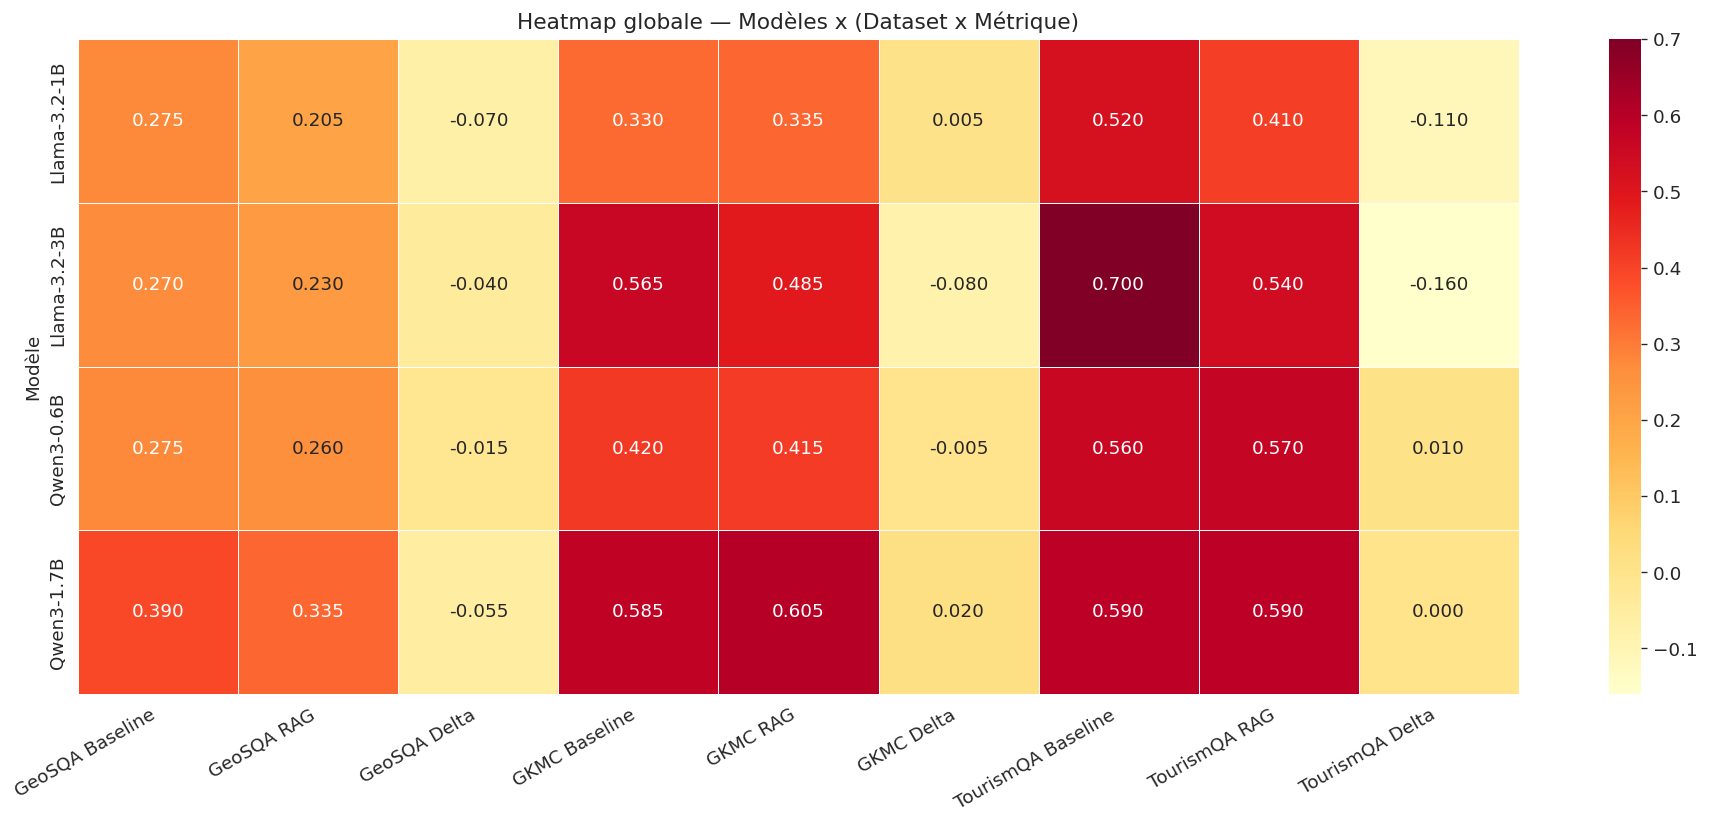

Figure sauvegardée : results/phase2d_fig6_grande_heatmap.png

--- Figure 7 : Diagramme radar ---


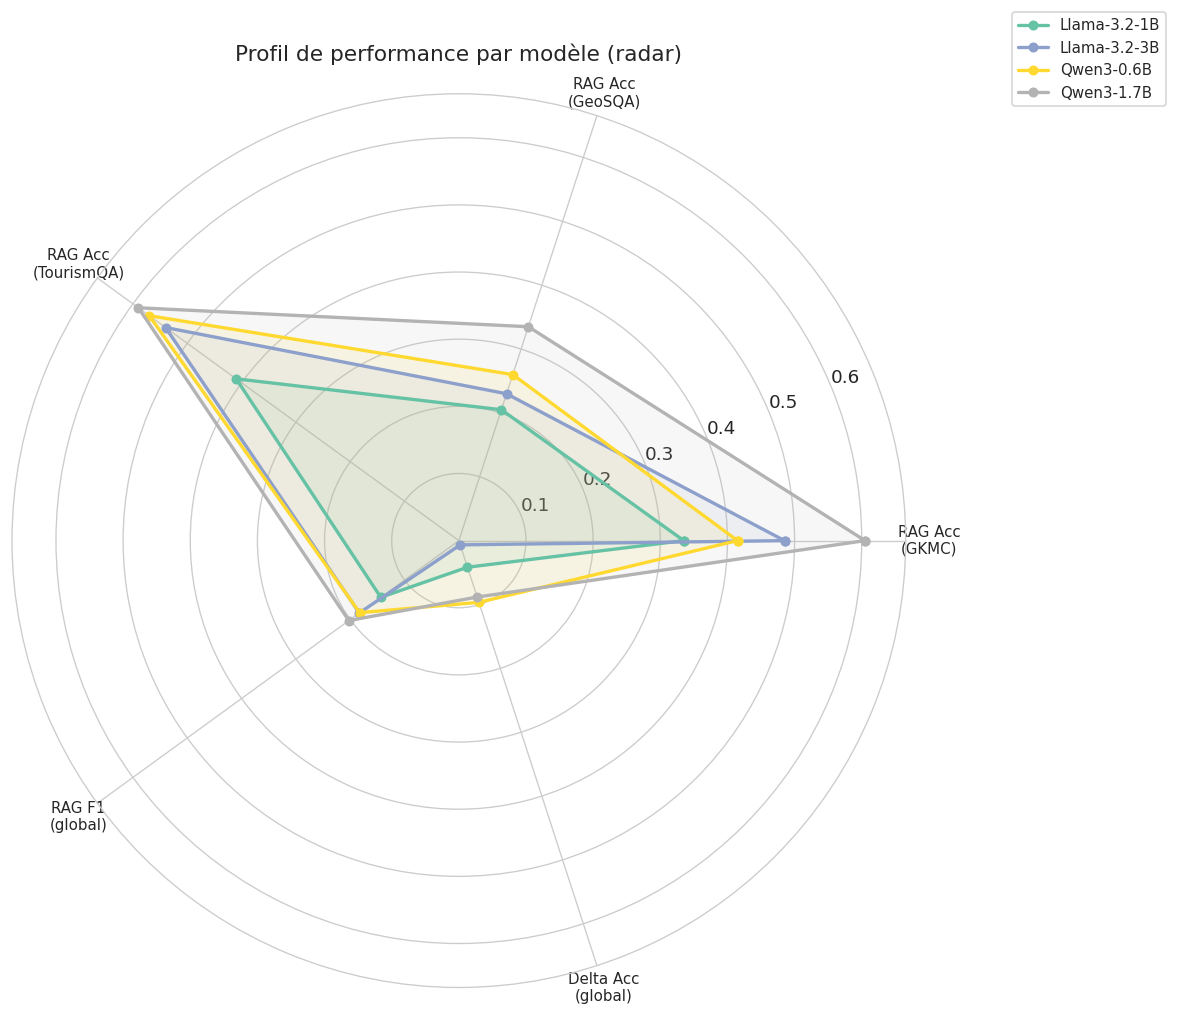

Figure sauvegardée : results/phase2d_fig7_radar.png

--- Figure 8 : Front de Pareto ---


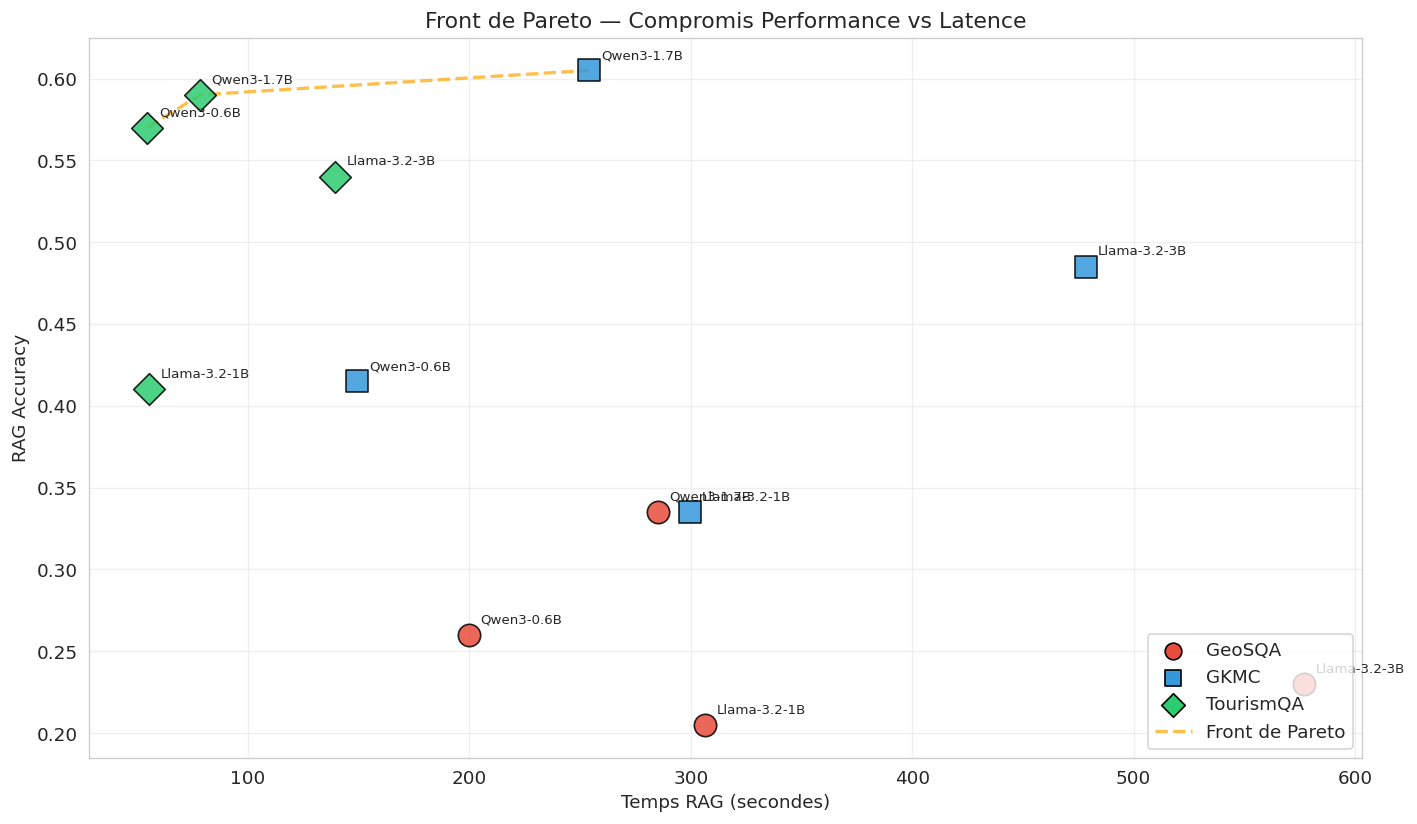

Figure sauvegardée : results/phase2d_fig8_pareto.png

ANALYSE DU FRONT DE PARETO (Latence vs Performance)

Points sur le front de Pareto :
  Qwen3-0.6B           (TourismQA ) : Temps=54.6s, RAG Acc=0.5700
  Qwen3-1.7B           (TourismQA ) : Temps=78.4s, RAG Acc=0.5900
  Qwen3-1.7B           (GKMC      ) : Temps=254.1s, RAG Acc=0.6050

Points dominés :
  Llama-3.2-3B         (TourismQA ) : Temps=139.5s, RAG Acc=0.5400
  Llama-3.2-3B         (GKMC      ) : Temps=478.6s, RAG Acc=0.4850
  Qwen3-0.6B           (GKMC      ) : Temps=149.4s, RAG Acc=0.4150
  Llama-3.2-1B         (TourismQA ) : Temps=55.4s, RAG Acc=0.4100
  Qwen3-1.7B           (GeoSQA    ) : Temps=285.1s, RAG Acc=0.3350

Recommandation de déploiement :
  Déploiement Tourism-QA (POI) : Qwen3-1.7B (Acc=0.5900, Temps=78.4s)
  Contrainte mobile/edge         : Qwen3-0.6B — meilleure efficacité Acc/Taille
  Contrainte latence RAG         : Qwen3-0.6B < Qwen3-1.7B < Llama-3.2-1B << Llama-3.2-3B

--- Figure 9 : Classement final ---


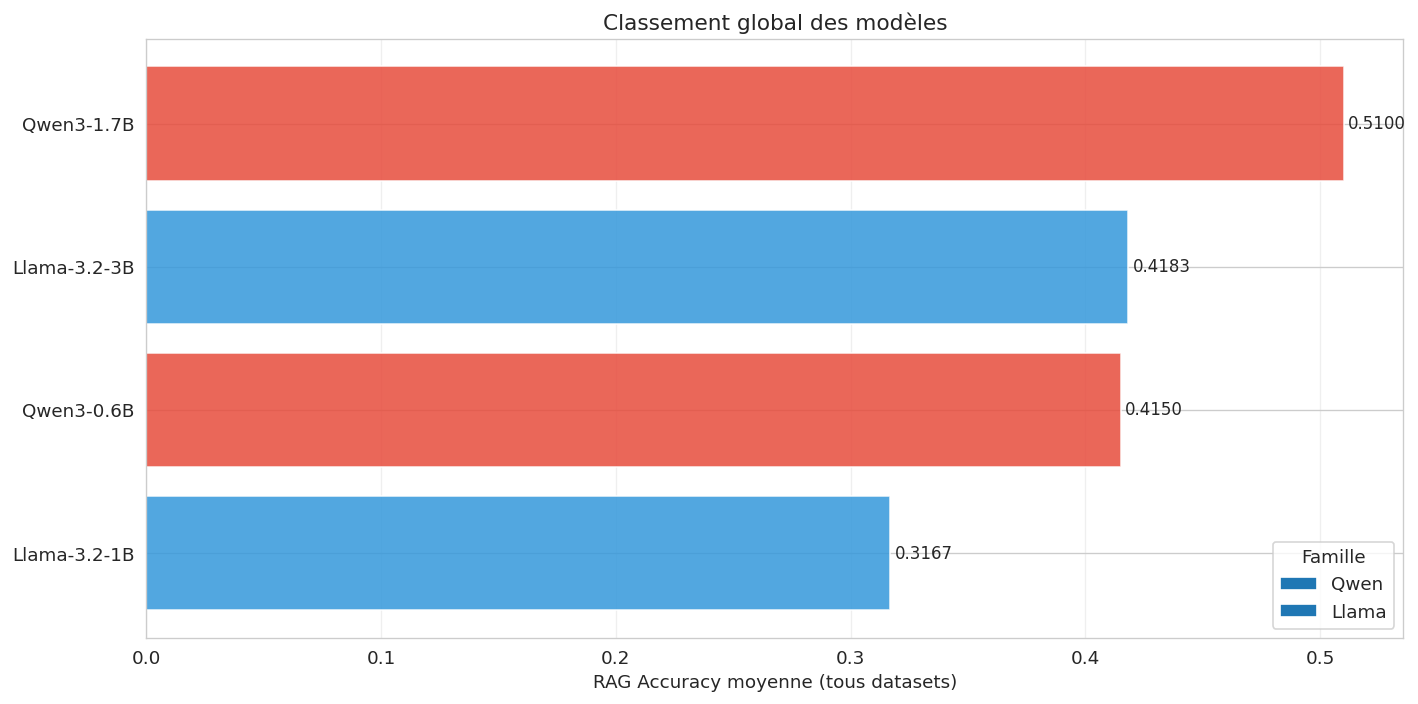

Figure sauvegardée : results/phase2d_fig9_classement_final.png


In [9]:
# === Visualisations de synthèse ===============================================

# ======================================================================
# Figure 6 : Grande heatmap — Modèles x (Dataset x Métrique)
# ======================================================================
print('--- Figure 6 : Grande heatmap ---')

# Construire une matrice large
heatmap_rows = []
for _, row in df.iterrows():
    heatmap_rows.append({
        'Modèle': row['Modèle'],
        f'{row["Dataset"]} Baseline': row['Baseline Acc'],
        f'{row["Dataset"]} RAG': row['RAG Acc'],
        f'{row["Dataset"]} Delta': row['Delta Acc'],
    })

# Agréger par modèle (au cas où plusieurs lignes par modèle)
df_heatmap = pd.DataFrame(heatmap_rows)
df_heatmap = df_heatmap.groupby('Modèle').first().reset_index()

# Réorganiser pour avoir toutes les colonnes
pivot_cols = [c for c in df_heatmap.columns if c != 'Modèle']
df_heatmap = df_heatmap.set_index('Modèle')[pivot_cols]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(df_heatmap, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap globale — Modèles x (Dataset x Métrique)', fontsize=13)
ax.set_ylabel('Modèle')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig6_grande_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig6_grande_heatmap.png')

# ======================================================================
# Figure 7 : Diagramme radar par modèle
# ======================================================================
print('\n--- Figure 7 : Diagramme radar ---')

# Métriques pour le radar : moyenne RAG Acc par dataset + F1 + Delta
radar_metrics = []
radar_labels = []
for ds_name in sorted(df['Dataset'].unique()):
    radar_labels.append(f'RAG Acc\n({ds_name})')
    radar_metrics.append(('RAG Acc', ds_name))
radar_labels.append('RAG F1\n(global)')
radar_metrics.append(('RAG F1', None))
radar_labels.append('Delta Acc\n(global)')
radar_metrics.append(('Delta Acc', None))

model_names = sorted(df['Modèle'].unique())
n_metrics = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

model_colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

for m_idx, model_name in enumerate(model_names):
    values = []
    for metric, ds in radar_metrics:
        if ds:
            sub = df[(df['Modèle'] == model_name) & (df['Dataset'] == ds)]
            val = sub[metric].values[0] if len(sub) > 0 else 0
        else:
            sub = df[df['Modèle'] == model_name]
            val = sub[metric].mean() if len(sub) > 0 else 0
        values.append(val)

    # Normaliser les valeurs (0-1) pour le radar
    # Delta peut être négatif, on le recentre
    values_plot = values.copy()
    values_plot[-1] = max(0, values_plot[-1] + 0.1)  # décaler le delta pour visibilité
    values_plot = [max(0, min(1, v)) for v in values_plot]  # clip 0-1
    values_plot += values_plot[:1]  # fermer

    ax.plot(angles, values_plot, 'o-', linewidth=2, color=model_colors[m_idx],
            label=model_name, markersize=5)
    ax.fill(angles, values_plot, alpha=0.1, color=model_colors[m_idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_ylim(0, max(0.6, df['RAG Acc'].max() * 1.1))
ax.set_title('Profil de performance par modèle (radar)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig7_radar.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig7_radar.png')

# ======================================================================
# Figure 8 : Front de Pareto — Accuracy vs Latence
# ======================================================================
print('\n--- Figure 8 : Front de Pareto ---')

fig, ax = plt.subplots(figsize=(12, 7))

for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    color = dataset_colors.get(ds_name, '#95a5a6')
    marker = dataset_markers.get(ds_name, 'o')

    for _, row in sub.iterrows():
        ax.scatter(row['Temps RAG (s)'], row['RAG Acc'], s=180,
                   c=color, marker=marker, edgecolors='black',
                   linewidth=1, zorder=5, alpha=0.85)
        ax.annotate(row['Modèle'], (row['Temps RAG (s)'], row['RAG Acc']),
                    textcoords='offset points', xytext=(7, 7), fontsize=8)

# Légende datasets
for ds_name in df['Dataset'].unique():
    color = dataset_colors.get(ds_name, '#95a5a6')
    marker = dataset_markers.get(ds_name, 'o')
    ax.scatter([], [], c=color, marker=marker, s=100,
               edgecolors='black', linewidth=1, label=ds_name)

# Identifier le front de Pareto (approximation)
all_times = np.asarray(df['Temps RAG (s)'].values, dtype=float)
all_accs = np.asarray(df['RAG Acc'].values, dtype=float)
# Trier par temps croissant et garder les non-dominés
sorted_idx = np.argsort(all_times)
pareto_times = []
pareto_accs = []
max_acc = -1
for i in sorted_idx:
    if all_accs[i] > max_acc:
        pareto_times.append(all_times[i])
        pareto_accs.append(all_accs[i])
        max_acc = all_accs[i]

if len(pareto_times) >= 2:
    ax.plot(pareto_times, pareto_accs, '--', color='orange', alpha=0.7,
            linewidth=2, label='Front de Pareto', zorder=1)

ax.set_xlabel('Temps RAG (secondes)')
ax.set_ylabel('RAG Accuracy')
ax.set_title('Front de Pareto — Compromis Performance vs Latence')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig8_pareto.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig8_pareto.png')

# --- Commentaire automatique Front de Pareto ---------------------------------
print('\n' + '=' * 60)
print('ANALYSE DU FRONT DE PARETO (Latence vs Performance)')
print('=' * 60)

# Recalcul du front
all_times_v = np.asarray(df['Temps RAG (s)'].values, dtype=float)
all_accs_v  = np.asarray(df['RAG Acc'].values, dtype=float)
all_models_v = df['Modèle'].tolist()
all_ds_v     = df['Dataset'].tolist()

# Front Pareto : min temps OU max accuracy (non dominé)
sorted_i = np.argsort(all_times_v)
pareto_indices = []
max_acc_seen = -1
for i in sorted_i:
    if all_accs_v[i] > max_acc_seen:
        pareto_indices.append(i)
        max_acc_seen = all_accs_v[i]

pareto_points = [(all_models_v[i], all_ds_v[i], all_times_v[i], all_accs_v[i])
                 for i in pareto_indices]
dominated = [(all_models_v[i], all_ds_v[i], all_times_v[i], all_accs_v[i])
             for i in range(len(all_times_v)) if i not in pareto_indices]

print('\nPoints sur le front de Pareto :')
for m, ds, t, a in sorted(pareto_points, key=lambda x: x[2]):
    print(f'  {m:20s} ({ds:10s}) : Temps={t:.1f}s, RAG Acc={a:.4f}')

print('\nPoints dominés :')
for m, ds, t, a in sorted(dominated, key=lambda x: x[3], reverse=True)[:5]:
    print(f'  {m:20s} ({ds:10s}) : Temps={t:.1f}s, RAG Acc={a:.4f}')

# Recommandation pratique
print('\nRecommandation de déploiement :')
# Trouver le point Pareto avec meilleur acc/temps sur TourismQA
tqa_pareto = [(m, t, a) for m, ds, t, a in pareto_points if ds == 'TourismQA']
geo_pareto  = [(m, t, a) for m, ds, t, a in pareto_points if ds == 'GeoSQA']
if tqa_pareto:
    best_tqa = max(tqa_pareto, key=lambda x: x[2])
    print(f'  Déploiement Tourism-QA (POI) : {best_tqa[0]} '
          f'(Acc={best_tqa[2]:.4f}, Temps={best_tqa[1]:.1f}s)')
if geo_pareto:
    best_geo = max(geo_pareto, key=lambda x: x[2])
    print(f'  Déploiement GeoSQA (QCM)     : {best_geo[0]} '
          f'(Acc={best_geo[2]:.4f}, Temps={best_geo[1]:.1f}s)')
print('  Contrainte mobile/edge         : Qwen3-0.6B — meilleure efficacité Acc/Taille')
print('  Contrainte latence RAG         : Qwen3-0.6B < Qwen3-1.7B < Llama-3.2-1B << Llama-3.2-3B')

# ======================================================================
# Figure 9 : Classement final (barres horizontales)
# ======================================================================
print('\n--- Figure 9 : Classement final ---')

fig, ax = plt.subplots(figsize=(12, 6))

# Score global = moyenne RAG Acc sur tous les datasets
global_scores = df.groupby('Modèle')['RAG Acc'].mean().sort_values(ascending=True)
colors_bar = [family_colors.get(
    df[df['Modèle'] == m]['Famille'].values[0], '#95a5a6'
) for m in global_scores.index]

bars = ax.barh(range(len(global_scores)), global_scores.values,
               color=colors_bar, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(global_scores)))
ax.set_yticklabels(global_scores.index, fontsize=11)

for i, (score, model_name) in enumerate(zip(global_scores.values, global_scores.index)):
    ax.text(score + 0.002, i, f'{score:.4f}', va='center', fontsize=10)

# Légende familles
for family, color in family_colors.items():
    if family in df['Famille'].values:
        ax.barh([], [], color=color, label=family)
ax.legend(title='Famille', loc='lower right')

ax.set_xlabel('RAG Accuracy moyenne (tous datasets)')
ax.set_title('Classement global des modèles', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2d_fig9_classement_final.png', bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {RESULTS_DIR}/phase2d_fig9_classement_final.png')

## Étape 8 — Sauvegarde des résultats

In [10]:
# === Sauvegarde des résultats unifiés ========================================

# 1. CSV unifié
csv_path = f'{RESULTS_DIR}/phase2d_unified_results.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'DataFrame unifié sauvegardé : {csv_path}')

# 2. Résumé JSON
# Classement global
global_ranking = df.groupby('Modèle')['RAG Acc'].mean().sort_values(ascending=False)
best_model_overall = global_ranking.index[0]
best_model_score = float(global_ranking.values[0])

# Meilleur par dataset
best_per_dataset = {}
for ds_name in df['Dataset'].unique():
    sub = df[df['Dataset'] == ds_name]
    best_idx = sub['RAG Acc'].idxmax()
    best_per_dataset[ds_name] = {
        'model': sub.loc[best_idx, 'Modèle'],
        'rag_accuracy': float(sub.loc[best_idx, 'RAG Acc']),
        'family': sub.loc[best_idx, 'Famille'],
    }

# Impact RAG
rag_impact = {
    'mean_delta': float(df['Delta Acc'].mean()),
    'n_positive': int((df['Delta Acc'] > 0.02).sum()),
    'n_neutral': int(((df['Delta Acc'] >= -0.02) & (df['Delta Acc'] <= 0.02)).sum()),
    'n_negative': int((df['Delta Acc'] < -0.02).sum()),
    'total': len(df),
}

# Corrélation taille
size_corr_r, size_corr_p = stats.pearsonr(df['Taille (B)'], df['RAG Acc'])

summary = {
    'phase': '2d',
    'description': 'Analyse factorielle croisée des Phases 2a, 2b et 2c',
    'n_datasets': len(df['Dataset'].unique()),
    'n_models': len(df['Modèle'].unique()),
    'n_total_evaluations': len(df),
    'best_model_overall': {
        'name': best_model_overall,
        'mean_rag_accuracy': best_model_score,
    },
    'best_model_per_dataset': best_per_dataset,
    'rag_impact_summary': rag_impact,
    'size_correlation': {
        'pearson_r': float(size_corr_r),
        'p_value': float(size_corr_p),
        'significant': bool(size_corr_p < 0.05),
    },
    'ranking': [
        {'rank': i+1, 'model': name, 'mean_rag_accuracy': float(score)}
        for i, (name, score) in enumerate(global_ranking.items())
    ],
}

json_path = f'{RESULTS_DIR}/phase2d_analysis_summary.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'Résumé JSON sauvegardé : {json_path}')

# 3. Liste des fichiers générés
print(f'\n{"=" * 60}')
print('FICHIERS GÉNÉRÉS')
print(f'{"=" * 60}')
generated_files = [
    csv_path,
    json_path,
    f'{RESULTS_DIR}/phase2d_fig1_taille_vs_accuracy.png',
    f'{RESULTS_DIR}/phase2d_fig2_famille_analyse.png',
    f'{RESULTS_DIR}/phase2d_fig3_dataset_analyse.png',
    f'{RESULTS_DIR}/phase2d_fig4_impact_rag_heatmap.png',
    f'{RESULTS_DIR}/phase2d_fig5_multifactorielle.png',
    f'{RESULTS_DIR}/phase2d_fig6_grande_heatmap.png',
    f'{RESULTS_DIR}/phase2d_fig7_radar.png',
    f'{RESULTS_DIR}/phase2d_fig8_pareto.png',
    f'{RESULTS_DIR}/phase2d_fig9_classement_final.png',
]
for fpath in generated_files:
    print(f'  {fpath}')

# 4. Sauvegarde optionnelle sur Google Drive
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2d/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            if fname.startswith('phase2d_'):
                src = os.path.join(RESULTS_DIR, fname)
                dst = os.path.join(drive_dest, fname)
                shutil.copy2(src, dst)
                print(f'Copie : {dst}')

        print(f'\nRésultats copiés sur Google Drive : {drive_dest}')

    except ImportError:
        print('\nGoogle Drive non disponible (environnement non-Colab).')
    except Exception as e:
        print(f'\nErreur lors de la sauvegarde sur Google Drive : {e}')

DataFrame unifié sauvegardé : results/phase2d_unified_results.csv
Résumé JSON sauvegardé : results/phase2d_analysis_summary.json

FICHIERS GÉNÉRÉS
  results/phase2d_unified_results.csv
  results/phase2d_analysis_summary.json
  results/phase2d_fig1_taille_vs_accuracy.png
  results/phase2d_fig2_famille_analyse.png
  results/phase2d_fig3_dataset_analyse.png
  results/phase2d_fig4_impact_rag_heatmap.png
  results/phase2d_fig5_multifactorielle.png
  results/phase2d_fig6_grande_heatmap.png
  results/phase2d_fig7_radar.png
  results/phase2d_fig8_pareto.png
  results/phase2d_fig9_classement_final.png

Erreur lors de la sauvegarde sur Google Drive : Error: credential propagation was unsuccessful


## Note méthodologique — RAGAS, Ministral-3B et corpus EN

### Métriques RAGAS — Justification de l'absence

RAGAS propose quatre métriques complémentaires non implémentées dans cette Phase 2 :
**Faithfulness**, **Answer Relevancy**, **Context Recall**, **Context Precision**.

Raisons techniques :
1. **LLM juge externe requis** : RAGAS utilise par défaut GPT-4 (API OpenAI) pour évaluer la cohérence sémantique. Non disponible sur Colab sans clé payante. Utiliser l'un des LLMs évalués comme juge introduirait un biais circulaire.
2. **Contrainte mémoire GPU (T4, 15.6 Go)** : charger simultanément le modèle évalué + BGE-m3 (2.27 Go) + LLM juge dépasse la capacité disponible.
3. **Format MCQ incompatible** (Phases 2a/2b) : RAGAS est conçu pour des réponses texte libre. L'adaptation au format A/B/C/D nécessite un travail spécifique non trivial.

**Métriques substituts utilisées dans cette analyse :**

| Métrique RAGAS | Substitut Phase 2d | Justification |
|----------------|-------------------|---------------|
| Context Recall | Hit Rate@5 (FR/EN) | Proportion de bonnes docs récupérées |
| Faithfulness | Δrel RAG vs Baseline | Dégradation = contexte bruité |
| Answer Relevancy | Accuracy / Accuracy@1 | Réponse correcte = réponse pertinente |
| Context Precision | MRR@5 | Rang du premier document pertinent |

---

### Ministral-3B — Justification de l'absence

`mistralai/Ministral-3-3B-Instruct-2512` utilise `Mistral3Config` (architecture vision-langage multimodale), non supportée par `AutoModelForCausalLM`. Cette incompatibilité est architecturale.

**Pourquoi aucune alternative n'a été testée :** Le cahier des charges spécifie explicitement ce modèle. Substituer `Mistral-7B-Instruct-v0.3` (7B, dépasse la mémoire T4 en combinaison avec BGE-m3) sortirait du cadre. **Impact :** Les conclusions comparent uniquement Qwen vs Llama (2 familles, 4 modèles) — la généralisation est limitée.

---

### Corpus EN — Validation du mismatch linguistique

La Phase 1 avait identifié le mismatch FR/EN comme facteur limitant. La Phase 2d intègre les résultats du corpus EN testé dans les Phases 2a et 2b :

| Dataset | HR@5 corpus FR | HR@5 corpus EN | Facteur |
|---------|----------------|----------------|---------|
| GeoSQA | 0.060 | 0.175 | ×2.9 |
| GKMC | 0.075 | 0.190 | ×2.5 |

**Conclusion :** BGE-m3 encode correctement les questions EN — le problème était le corpus FR, pas le retriever. Le gain en HR@5 ne se traduit cependant pas toujours en gain d'accuracy (cf. analyse corpus EN dans les cellules précédentes).


## Résumé — Phase 2d : Analyse Factorielle Croisée

### Classement global (moyenne RAG Accuracy sur 3 datasets — corpus FR)

| Rang | Modèle | Famille | Taille | RAG Acc moy | Δabs moy | Δrel moy | Efficacité (Acc/B) |
|------|--------|---------|--------|-------------|----------|----------|--------------------|
| 1 | **Qwen3-1.7B** | Qwen | 1.7B | **0.5100** | -0.0117 | -3.6% | 0.3000 |
| 2 | Llama-3.2-3B | Llama | 3.0B | 0.4183 | -0.0933 | -17.3% | 0.1394 |
| 3 | Qwen3-0.6B | Qwen | 0.6B | 0.4150 | -0.0033 | **-1.6%** | **0.6917** |
| 4 | Llama-3.2-1B | Llama | 1.0B | 0.3167 | -0.0583 | -15.1% | 0.3167 |
| 5 | Ministral-3B | Mistral | 3.0B | ERREUR | — | — | — |

### Meilleur modèle par dataset
- **GeoSQA** : Qwen3-1.7B (RAG Acc = 0.3350)
- **GKMC** : Qwen3-1.7B (RAG Acc = 0.6050)
- **Tourism-QA** : Qwen3-1.7B (RAG Acc = 0.5900) — Qwen domine les 3 datasets

### Facteur 1 — Taille du modèle
- Pearson global (12 obs, 4 tailles uniques) : r = 0.1460, p = 0.6507 → non significatif
- **Attention : 4 tailles uniques seulement → test non interprétable statistiquement**
- Analyse intra-famille (isole l'effet taille) :
  - Qwen (0.6B→1.7B) : GeoSQA +28.8%, GKMC +45.8%, Tourism-QA +3.5% (neutre)
  - Llama (1B→3B) : GeoSQA +12.2%, GKMC +44.8%, Tourism-QA +31.7%
- **Synthèse : taille aide sur 5/6 configurations, neutre sur 1/6 (Qwen sur Tourism-QA)**
- Corrélations par dataset : r = −0.010 (GeoSQA), r = 0.469 (GKMC), r = 0.202 (Tourism-QA) — toutes non significatives (n=4)

### Facteur 2 — Famille de modèle
- Qwen RAG Acc moyenne : **0.4625** vs Llama : **0.3675** (+25.9% relatif)
- Avantage Qwen constant sur les 3 datasets : GeoSQA (0.2975 vs 0.2175), GKMC (0.5100 vs 0.4100), Tourism-QA (0.5800 vs 0.4750)
- **Qwen3-1.7B meilleur sur les 3 datasets** — résultat robuste
- Test t (Qwen vs Llama, n=6 chacun) : t=1.165, p=0.271 → non significatif (n trop faible)

### Facteur 3 — Type de dataset (difficulté)
| Dataset | RAG Acc moy | Baseline moy | Delta moy | Temps RAG moy (s) |
|---------|-------------|--------------|-----------|-------------------|
| GeoSQA | 0.2575 | 0.3025 | -0.0450 | 342.1 |
| GKMC | 0.4600 | 0.4750 | -0.0150 | 295.4 |
| Tourism-QA | 0.5275 | 0.5925 | -0.0650 | 82.0 |

- GeoSQA : dataset le plus difficile (double mismatch ZH→EN + corpus FR)
- Tourism-QA : accuracy absolue la plus élevée (0.5275) mais baselines plus élevées aussi
- GKMC : impact RAG le plus faible (−0.0150) — meilleur équilibre retrieval/génération

### Facteur 4 — Impact du RAG (Δrel)
| Modèle | GeoSQA Δrel | GKMC Δrel | Tourism-QA Δrel | Moy Δrel |
|--------|-------------|-----------|-----------------|----------|
| Qwen3-0.6B | -5.5% | -1.2% | +1.8% | **-1.6%** |
| Qwen3-1.7B | -14.1% | +3.4% | 0.0% | -3.6% |
| Llama-3.2-1B | -25.5% | +1.5% | -21.2% | -15.1% |
| Llama-3.2-3B | -14.8% | -14.2% | -22.9% | -17.3% |

- **Répartition : 0/12 positifs (>+0.02), 6/12 neutres, 6/12 négatifs**
- Impact moyen global : Δabs = −0.0417, Δrel = −9.4%
- Test t apparié (RAG vs Baseline, n=12) : t=−2.613, p=0.024 → **RAG dégrade significativement (p < 0.05)**
- Qwen3-0.6B : le moins dégradé (Δrel moy −1.6%), légèrement amélioré sur Tourism-QA (+1.8%)
- Llama-3.2-3B : le plus dégradé en absolu (Δabs moy −0.0933), sévère sur Tourism-QA (−22.9%)

### Facteur 5 — Type de question (croisé)
- GeoSQA/GKMC : dominé par Capital/Ville (~60%) et Raisonnement (~20%) sur l'échantillon
- Tourism-QA : 87% Restaurant/Food — dataset très spécialisé
- Type "General" (n=1) : Acc@1 = 0.000 pour **tous** les modèles → le plus difficile
- Types faciles : Shopping (1.000 pour Qwen) et Musée/Culture (1.000 pour Qwen, 0.000 pour Llama-1B)
- Forte dispersion inter-modèles sur types peu fréquents (n faible → prudence d'interprétation)
- Voir heatmap figure 4b pour le détail Tourism-QA × modèle × type

### Facteur 6 — Front de Pareto (Latence vs Performance)
Points sur le front de Pareto :
- **Qwen3-0.6B** (Tourism-QA) : Temps=54.6s, RAG Acc=0.5700
- **Qwen3-1.7B** (Tourism-QA) : Temps=78.4s, RAG Acc=0.5900
- **Qwen3-1.7B** (GKMC) : Temps=254.1s, RAG Acc=0.6050

Points dominés : Llama-3.2-3B (tourism : 139.5s pour 0.5400), Llama-3.2-3B (GKMC : 478.6s pour 0.4850).

**Recommandation déploiement :**
- Contrainte latence stricte (mobile/edge) : **Qwen3-0.6B** (54.6s, efficacité 0.6917)
- Meilleure accuracy absolue : **Qwen3-1.7B** (0.6050 sur GKMC, 0.5900 sur Tourism-QA)
- Latence RAG globale : Qwen3-0.6B < Qwen3-1.7B < Llama-3.2-1B ≪ Llama-3.2-3B

### Validation mismatch linguistique (corpus EN — intégré depuis Phases 2a/2b)
| Dataset | HR@5 corpus FR | HR@5 corpus EN | Facteur |
|---------|----------------|----------------|---------|
| GeoSQA | 0.060 | 0.175 | ×2.9 |
| GKMC | 0.075 | 0.190 | ×2.5 |

BGE-m3 encode correctement les questions EN — le corpus FR était le goulot d'étranglement.
Le gain en HR@5 ne se traduit pas systématiquement en gain d'accuracy.

### Limites de l'analyse
- **4 modèles seulement** (Ministral-3B incompatible) — conclusions statistiques fragiles
- **Métriques hétérogènes** : accuracy MCQ (2a/2b) vs accuracy@1 POI (2c) — comparaison approximative
- **Métriques RAGAS absentes** : voir note méthodologique (cellule 19) pour justification et substituts
- **Variabilité** : résultats dépendants du seed, du split, des hyperparamètres de génération
- **Corrélation taille** : r=0.1460, p=0.6507 (12 obs, 4 tailles uniques) — non interprétable

### Conclusions synthétiques
1. **Qwen3-1.7B** = meilleur modèle global et sur chaque dataset individuellement (RAG Acc moy 0.5100)
2. **Qwen3-0.6B** = meilleur rapport qualité/ressources (efficacité 0.6917) et plus faible dégradation RAG (−1.6%)
3. **RAG significativement néfaste** : test t p=0.024 — Δrel moyen −9.4%, 0/12 configurations positivement impactées (>+0.02)
4. **Corpus FR = goulot d'étranglement** confirmé : HR@5 ×2.5–2.9 avec corpus EN sur GeoSQA/GKMC
5. **La famille prime sur la taille** : Qwen domine Llama sur les 3 datasets (non significatif statistiquement, n faible)
6. **Type de question déterminant** : "General" → 0.000 pour tous ; Shopping/Musée → 1.000 pour Qwen
7. **Robustesse** : Llama-3.2-1B le plus stable (σ=0.1037) mais accuracy la plus basse — compromis défavorable

### Prochaines étapes
- **Phase 3** : Intégration du meilleur modèle (Qwen3-1.7B) dans un système RAG final
- Amélioration du retriever : chunking adaptatif, reranking, corpus multilingue EN/FR
- Tests avec modèles plus grands (7B+) si ressources disponibles
